# Plots for 2021 Atmospheric River

In [29]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature
#import cartopy.mpl.ticker as cticker
import geopandas as gpd

%config InlineBackend.figure_format = "retina"
%matplotlib inline

## Load data 

PRISM, HRRR, WRF

In [30]:
# PRISM as benchmark
# NOTE: 1D Coords
zarr_path = '../data/weather_data/2021-11-10_2021-11-17_daily_4km_PRISM_data.zarr'
dsPRISM = xr.open_zarr(zarr_path, chunks=None) #ppt (mm)
#dsPRISM # ppt =
daP = dsPRISM.ppt

In [31]:
# PRISM as benchmark
# NOTE: 1D Coords
zarr_path = '../data/weather_data/2021-11-10_2021-11-17_daily_800m_PRISM_data.zarr' # lat: 163lon: 207
daP8 = xr.open_zarr(zarr_path, chunks=None).ppt
daP8

<xarray.DataArray 'ppt' (time: 8, lat: 163, lon: 207)> Size: 1MB
[269928 values with dtype=float32]
Coordinates:
    crs      int64 8B ...
  * lat      (lat) float64 1kB 49.31 49.3 49.29 49.28 ... 47.98 47.97 47.96
  * lon      (lon) float64 2kB -122.4 -122.4 -122.4 ... -120.7 -120.7 -120.7
  * time     (time) datetime64[ns] 64B 2021-11-10 2021-11-11 ... 2021-11-17
Attributes:
    Conventions:        CF-1.5
    GDAL:               GDAL 3.4.3, released 2022/04/22
    history:            Fri Nov 07 16:54:29 2025: GDAL CreateCopy( /nfs/panca...
    lat#long_name:      latitude
    lat#standard_name:  latitude
    lat#units:          degrees_north
    lon#long_name:      longitude
    lon#standard_name:  longitude
    lon#units:          degrees_east
    long_name:          GDAL Band Number 1

In [32]:
# HRRR is hourly data
zarr_path = '../data/weather_data/2021-11-10_2021-11-17_HRRR_data.zarr'
#
dsHRRR = xr.open_zarr(zarr_path, chunks=None) # tp = accum total precip (units = mm)
daH = dsHRRR.tp
daH = daH.where(daH != 0, np.nan)

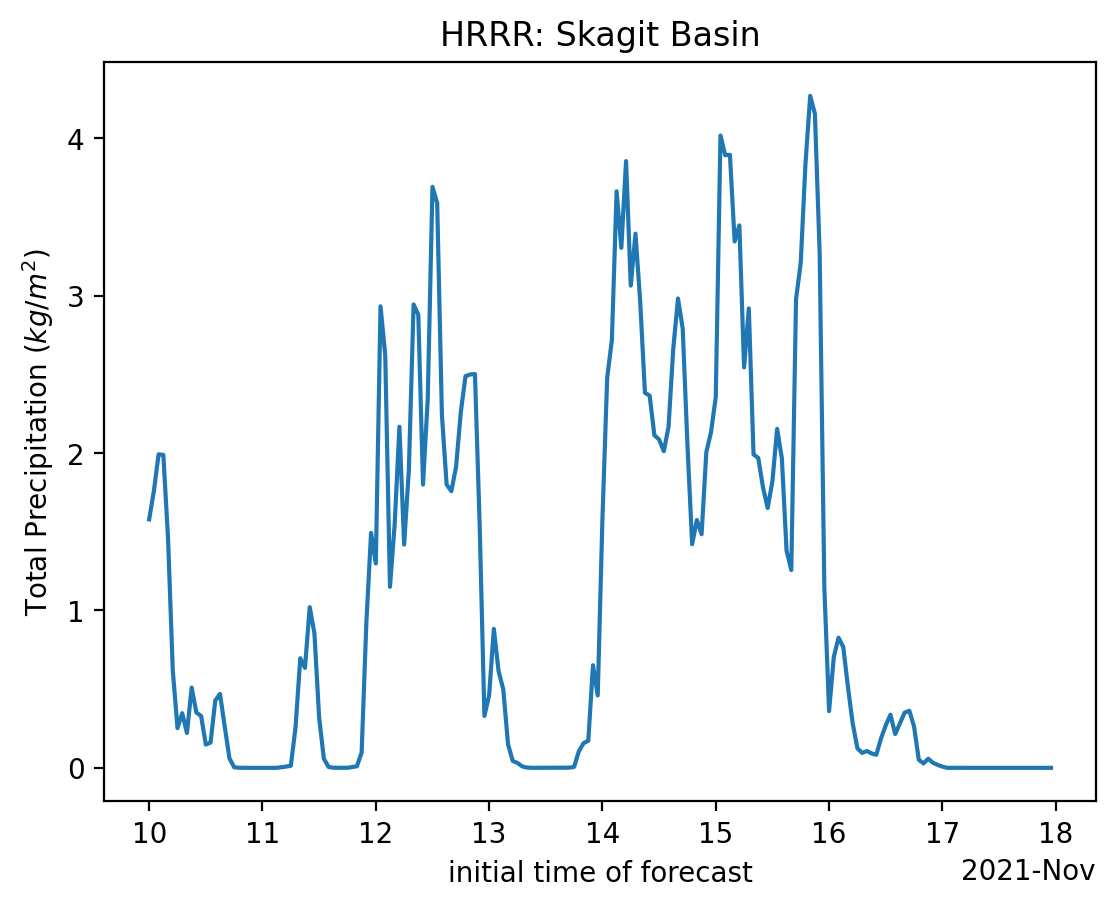

In [33]:
# Hourly best shows timing of precipitation events
dsHRRR.mean(dim=['x','y']).tp.plot()
plt.title('HRRR: Skagit Basin')
# NOTE: 1 kg/m^2 ~ 1mm of water
plt.ylabel('Total Precipitation ($kg/m^{2}$)');

In [34]:
# # NOTE: might be easiest just to re-mask after certain operations
# def maskDataset(ds: xr.Dataset, mask_file: str) -> xr.Dataset:
#   mask_shape = gpd.read_file(mask_file)
#   mask = shapely.contains_xy(mask_shape.geometry[0], ds.longitude.values, ds.latitude.values)
#   masked_data_set = ds.where(mask)

#   return masked_data_set

In [35]:
# dsHRRR.tp # GRIB_missingValue :3.4028234663852886e+38
# dsHRRR.tp.isel(time=28).plot() # time=23-25 back to zero for a bit

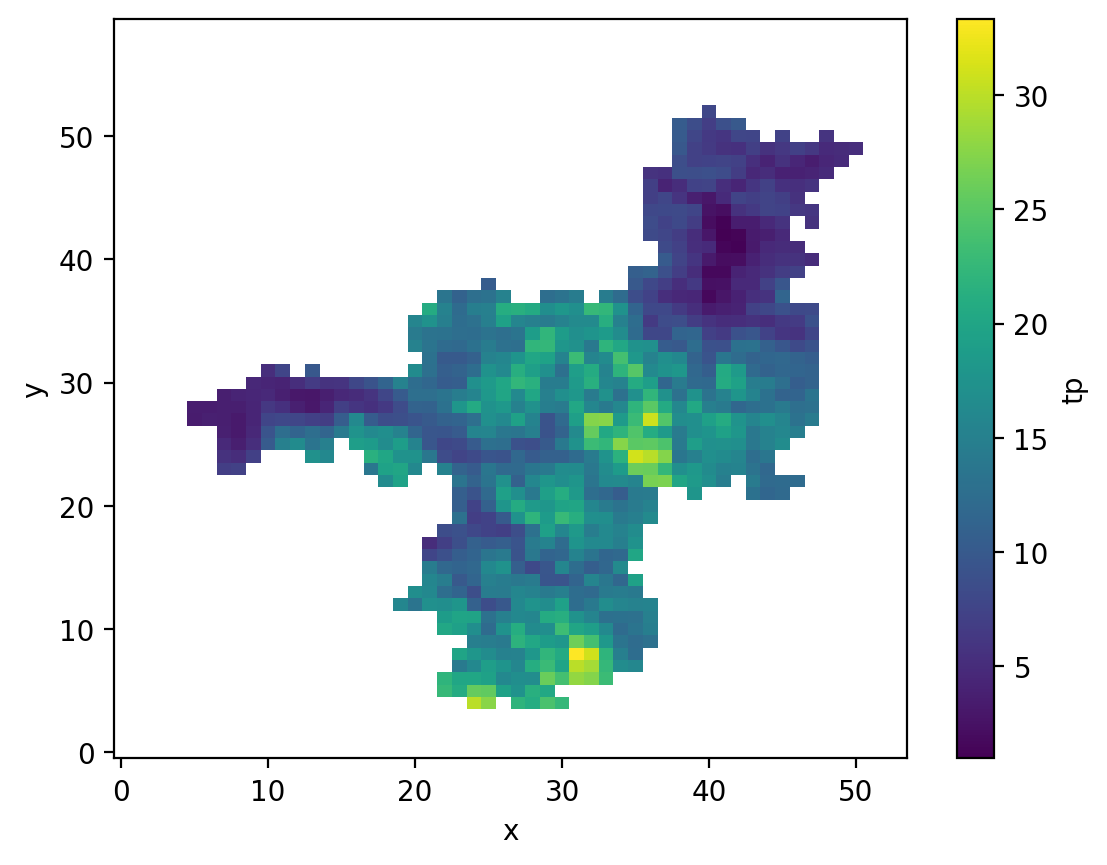

In [36]:
# NOTE: xarray by default sums nans -> 0
daH.sel(time='2021-11-10').sum(dim='time', min_count=1).plot();
#daH.sel(time='2021-11-10').mean(dim='time').plot() # keeps nana
#daH.sel(time='2021-11-10')

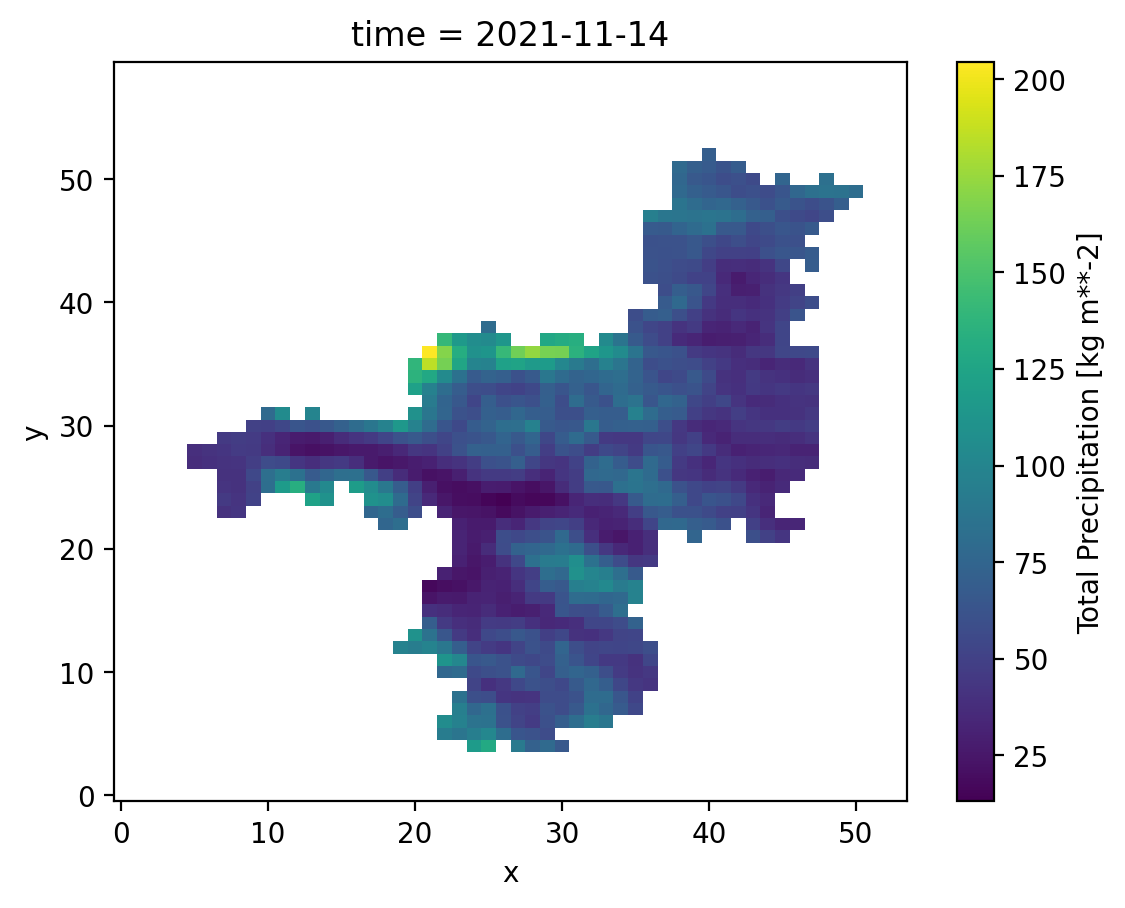

In [37]:
dsHRRR.resample(time='1D').sum(min_count=1).sel(time='2021-11-14').tp.plot();

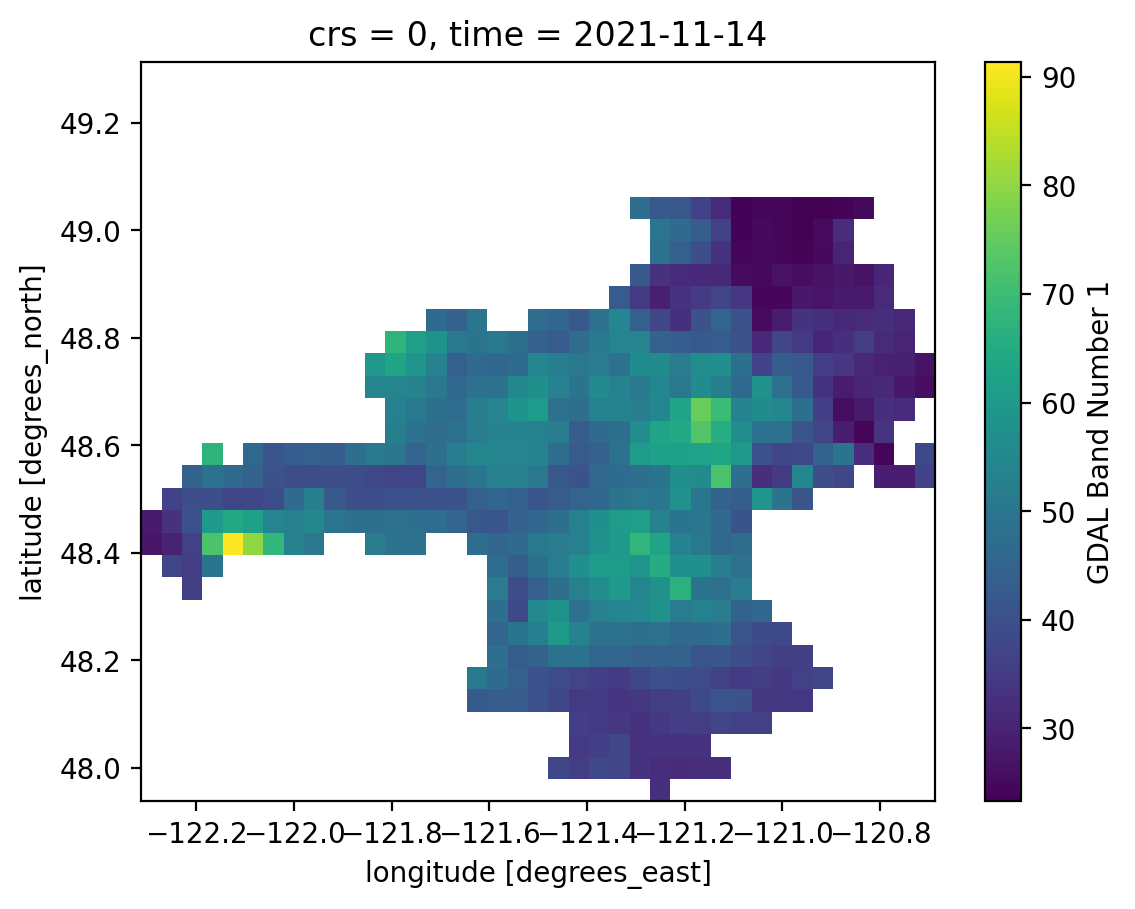

In [38]:
dsPRISM.sel(time='2021-11-14').ppt.plot();

In [39]:
# Construct dataframe of daily precipitation
dfP = daP.mean(dim=['lat','lon']).drop_vars('crs').to_dataframe(name='PRISM')
dfH = daH.resample(time='1D').sum(min_count=1).mean(dim=['x','y']).to_dataframe(name='HRRR')
df = dfP.join(dfH)

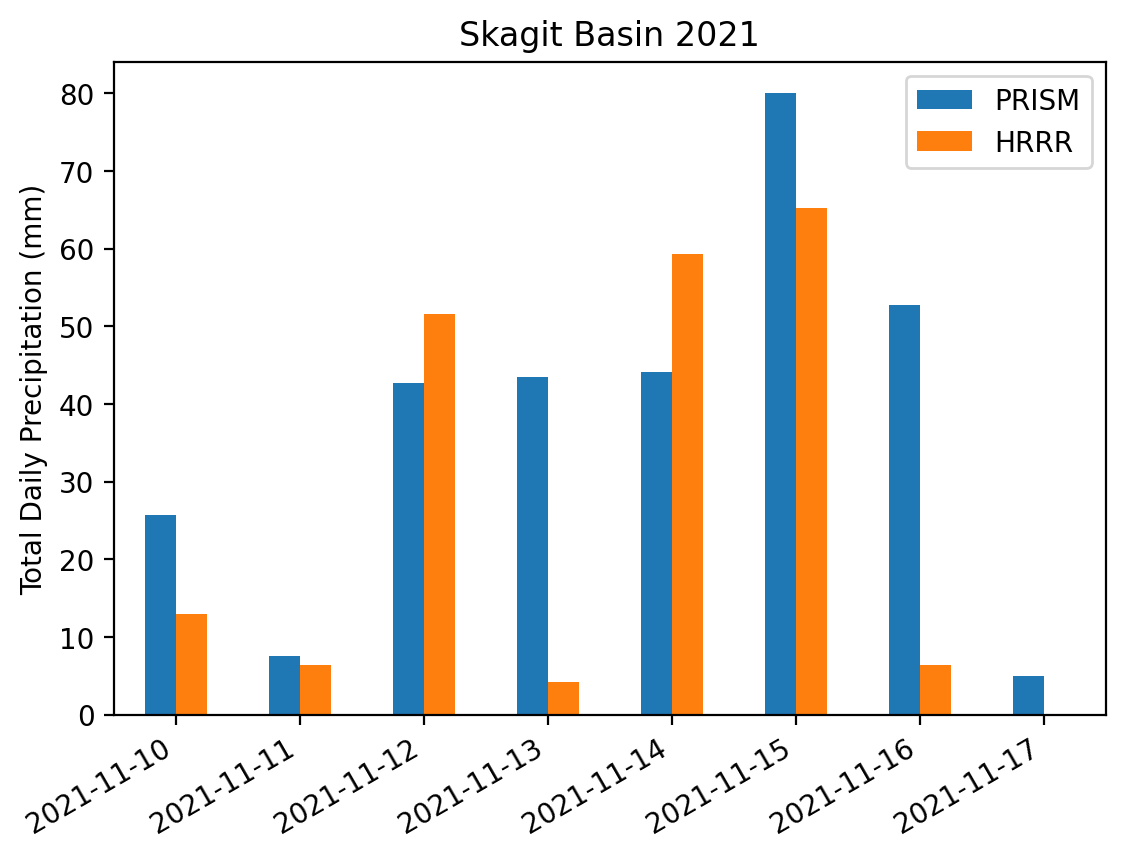

In [40]:
df.index = df.index.date
fig,ax=plt.subplots()
df.plot.bar(ax=ax)
plt.title('Skagit Basin 2021')
plt.ylabel('Total Daily Precipitation (mm)')
fig.autofmt_xdate()

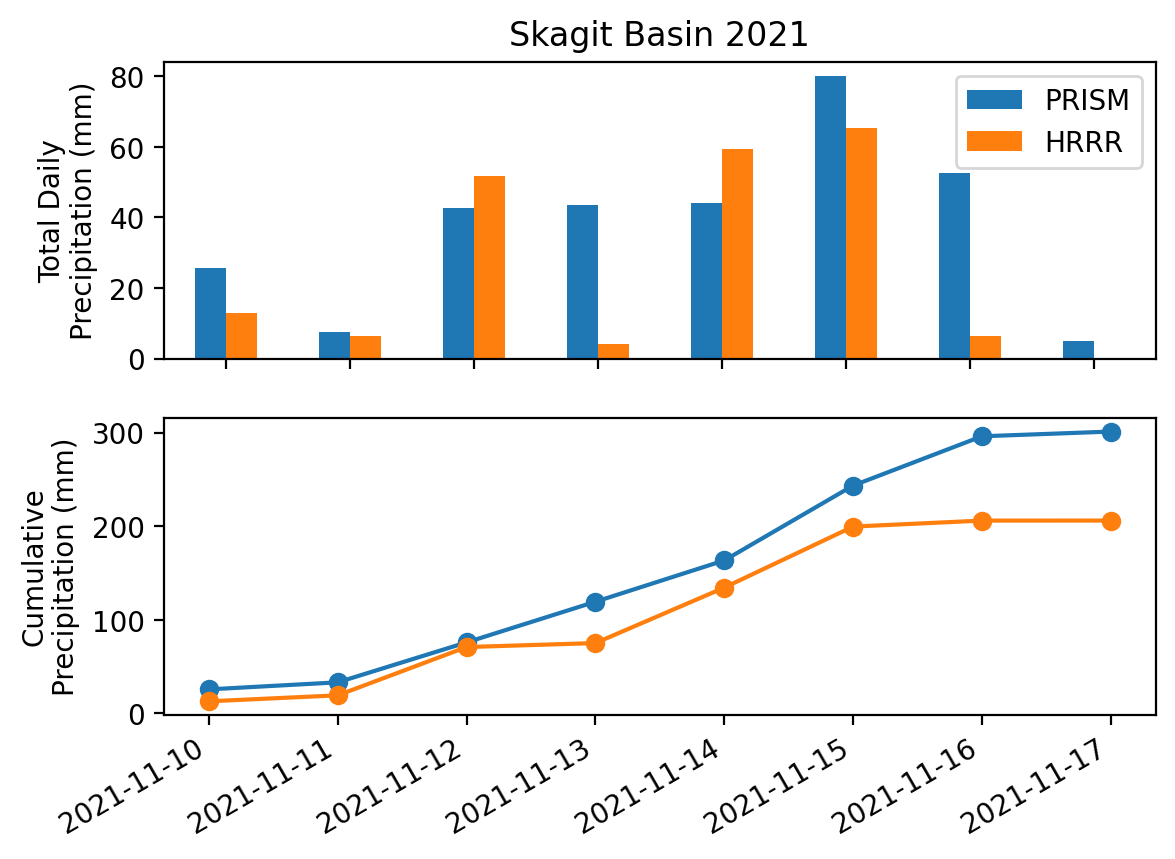

In [41]:
# NOTE: also show HRRR hourly here?
# For some reason sharex=True not showing second plot here....
fig, axs=plt.subplots(2,1)
ax = axs[0]
df.plot.bar(ax=ax)
ax.set_title('Skagit Basin 2021')
ax.set_ylabel('Total Daily\nPrecipitation (mm)')
#ax.legend(loc='upper left')
df.cumsum().plot.line(ax=axs[1], marker='o', legend=False)
axs[1].set_ylabel('Cumulative\nPrecipitation (mm)')
fig.autofmt_xdate()

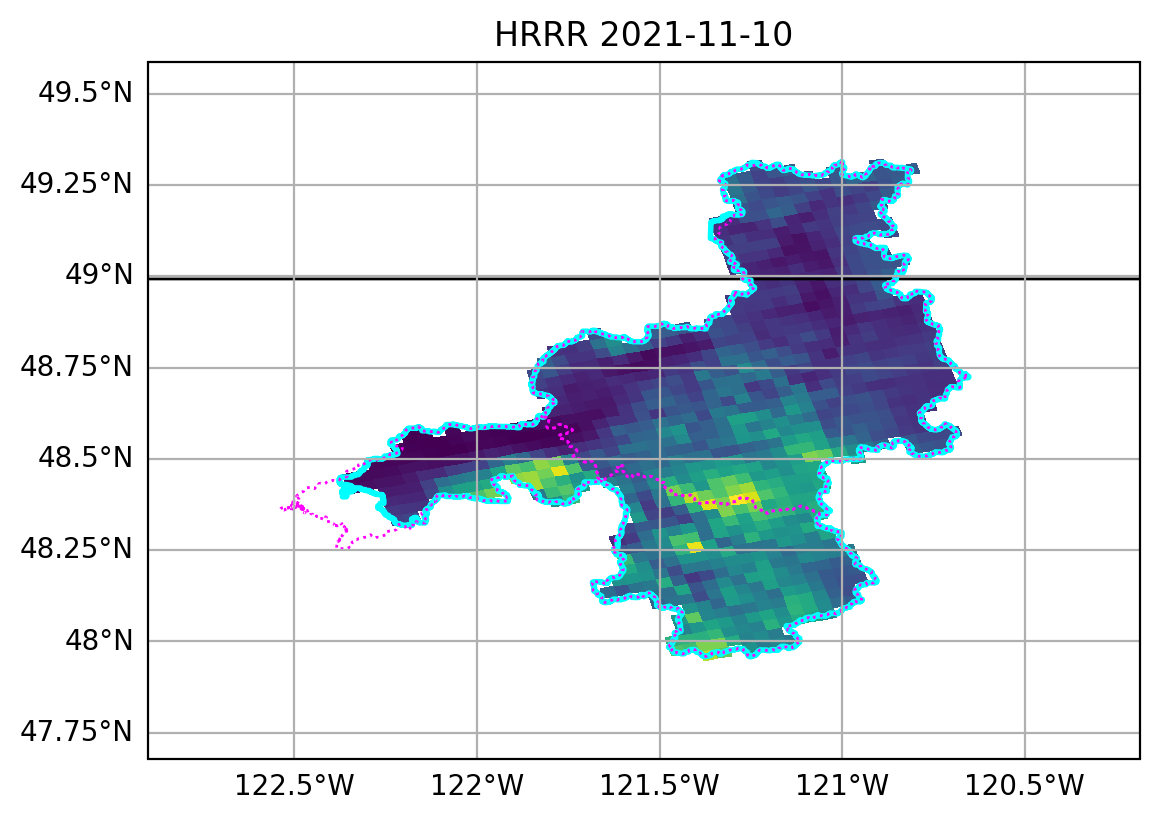

In [42]:
#plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

da = dsHRRR.tp.isel(time=0)

da.plot.pcolormesh(
    ax=ax, transform=ccrs.PlateCarree(), x="longitude", y="latitude", add_colorbar=False
)
# Add canadian border
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=1)

# Add main Basin boundary
aoi_path = '../data/GIS/SkagitBoundary.json'
mask = gpd.read_file(aoi_path)
ax.add_geometries([mask.geometry[0]], ccrs.PlateCarree(), edgecolor='cyan', facecolor='None', linewidth=2);

# Add subbasin boundaries
gf_sub = gpd.read_file('../data/GIS/SkagitSubBasin_HUC8.geojson')
gf_sub = gf_sub[gf_sub.Name.isin(['Upper Skagit', 'Lower Skagit', 'Sauk'])]
ax.add_geometries(gf_sub.geometry, ccrs.PlateCarree(), facecolor='None', edgecolor='magenta', linewidth=1, linestyle='dotted');

# Different colors or labels for subbasins
# colors = ['red', 'blue', 'green']
# for geom, color in zip(gf_sub.geometry, colors):
#   ax.add_geometries([geom], ccrs.PlateCarree(), facecolor='None', edgecolor=color, linewidth=1, linestyle='dotted');

# Mt Baker & Glacier Peak locations
#mt_baker_lat_lon = (48.7758, -121.8199)
#gl_peak_lat_lon = (48.1048, -121.1124)

gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

ax.set_title(f'HRRR {str(da.time.dt.date.values)}');

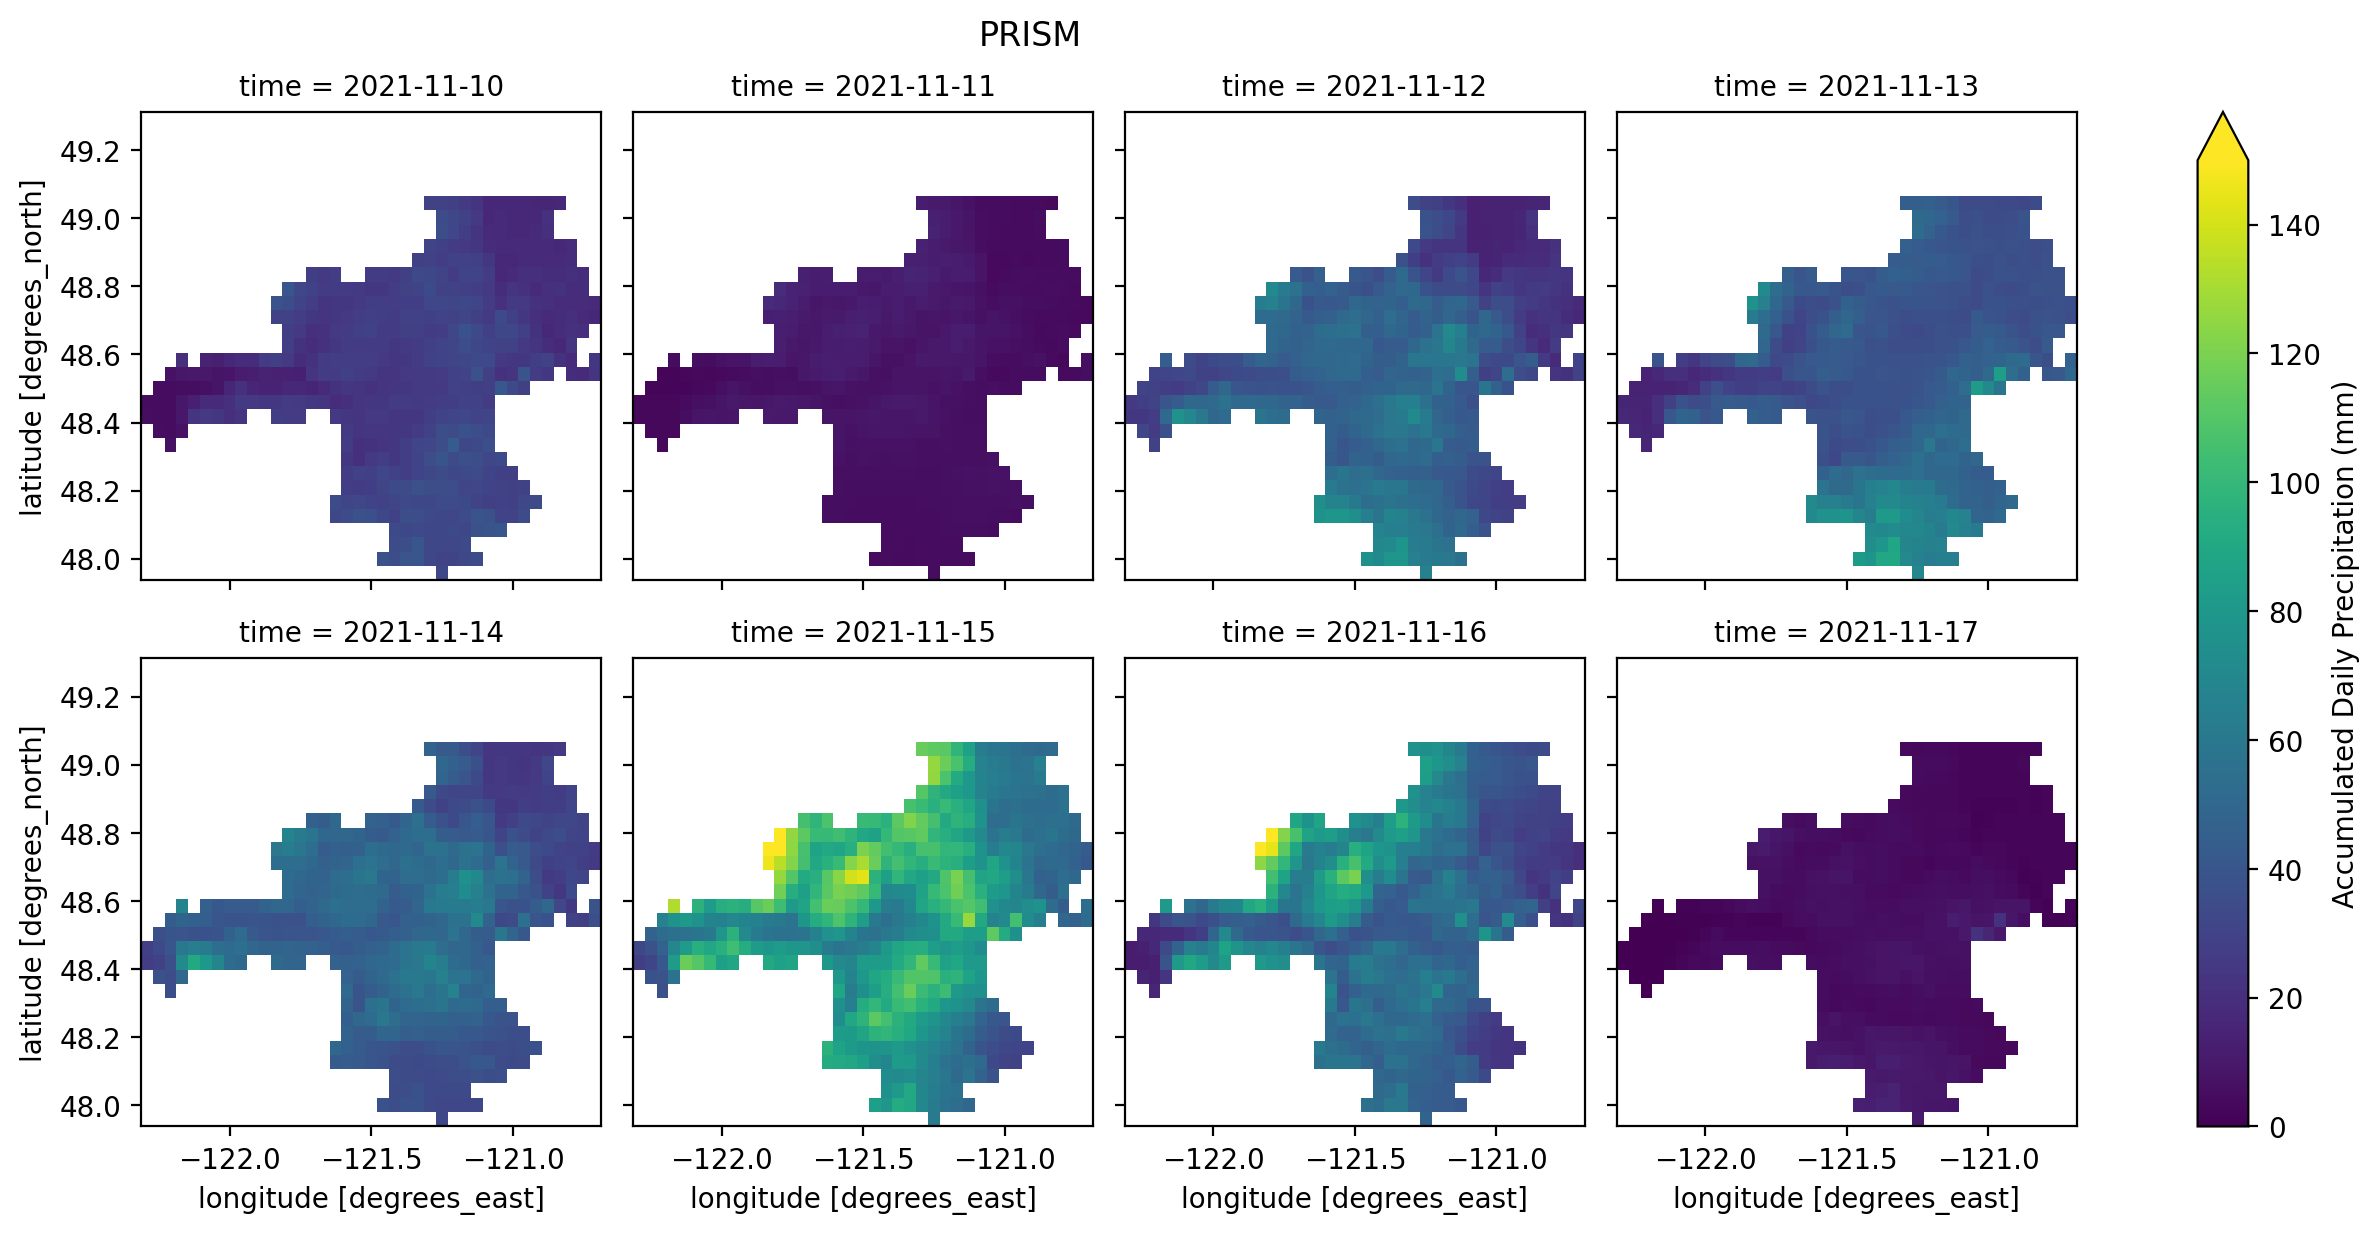

In [43]:
a = daP.plot.imshow(col='time', col_wrap=4, cmap='viridis', vmin=0, vmax=150,
                    cbar_kwargs={'label': 'Accumulated Daily Precipitation (mm)'},
)
a.fig.suptitle('PRISM', x=0.4, y=1.02);


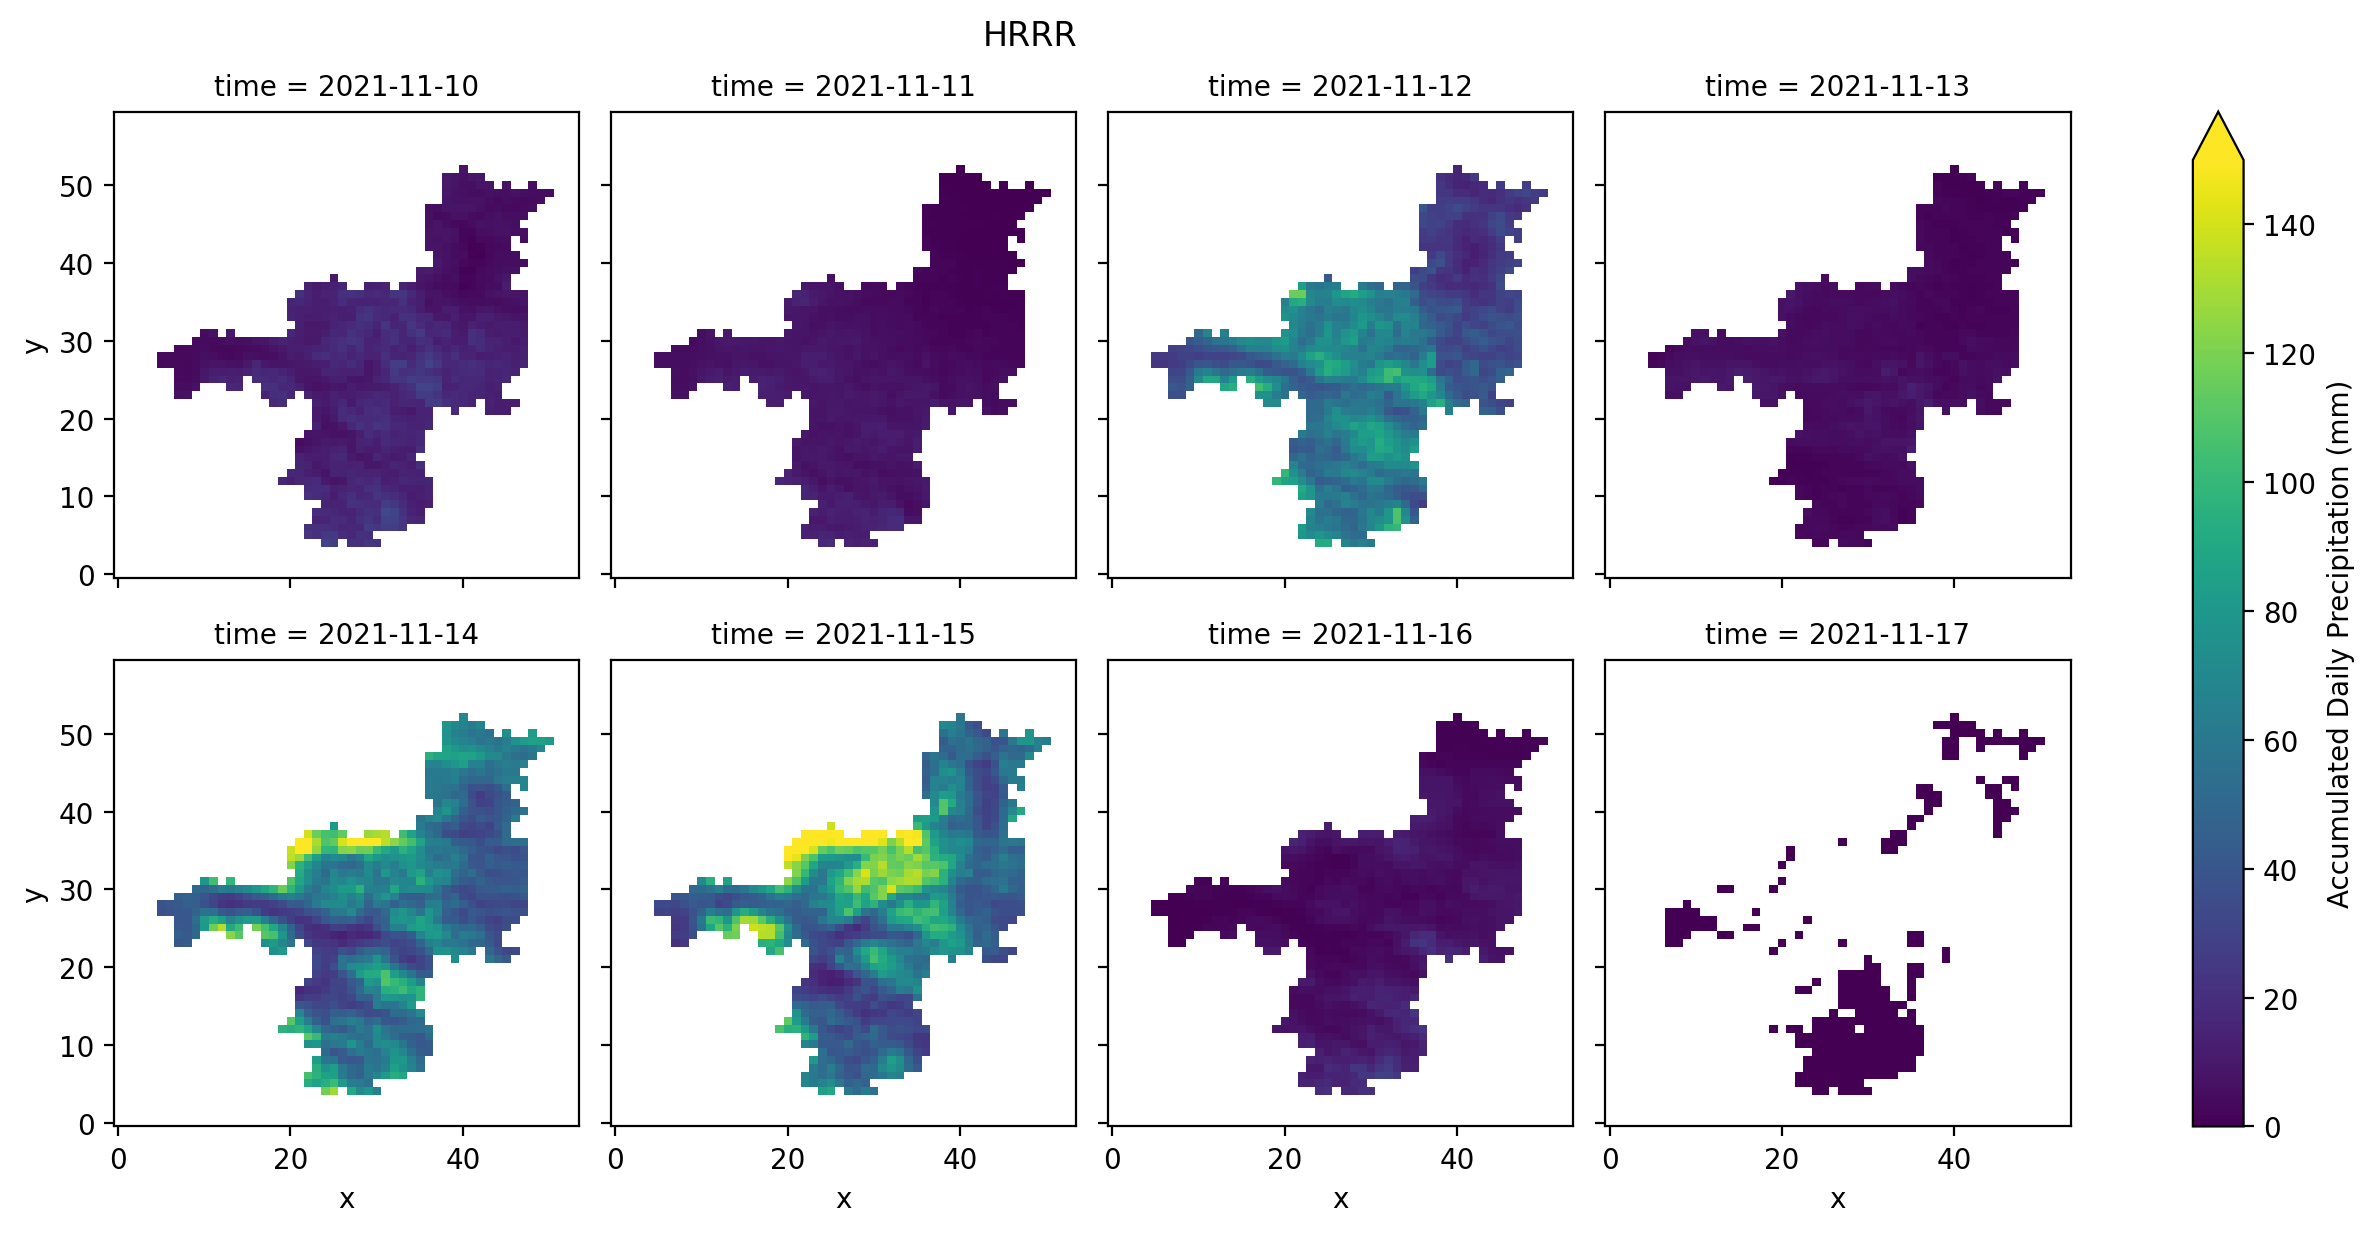

In [44]:
# Dhow log scale here?
#daH.resample(time='1D').sum(min_count=1)
a = daH.resample(time='1D').sum(min_count=1).plot.imshow(col='time', col_wrap=4, cmap='viridis', vmin=0, vmax=150,
                                                         cbar_kwargs={'label': 'Accumulated Daily Precipitation (mm)'},
)
a.fig.suptitle('HRRR', x=0.4, y=1.02);

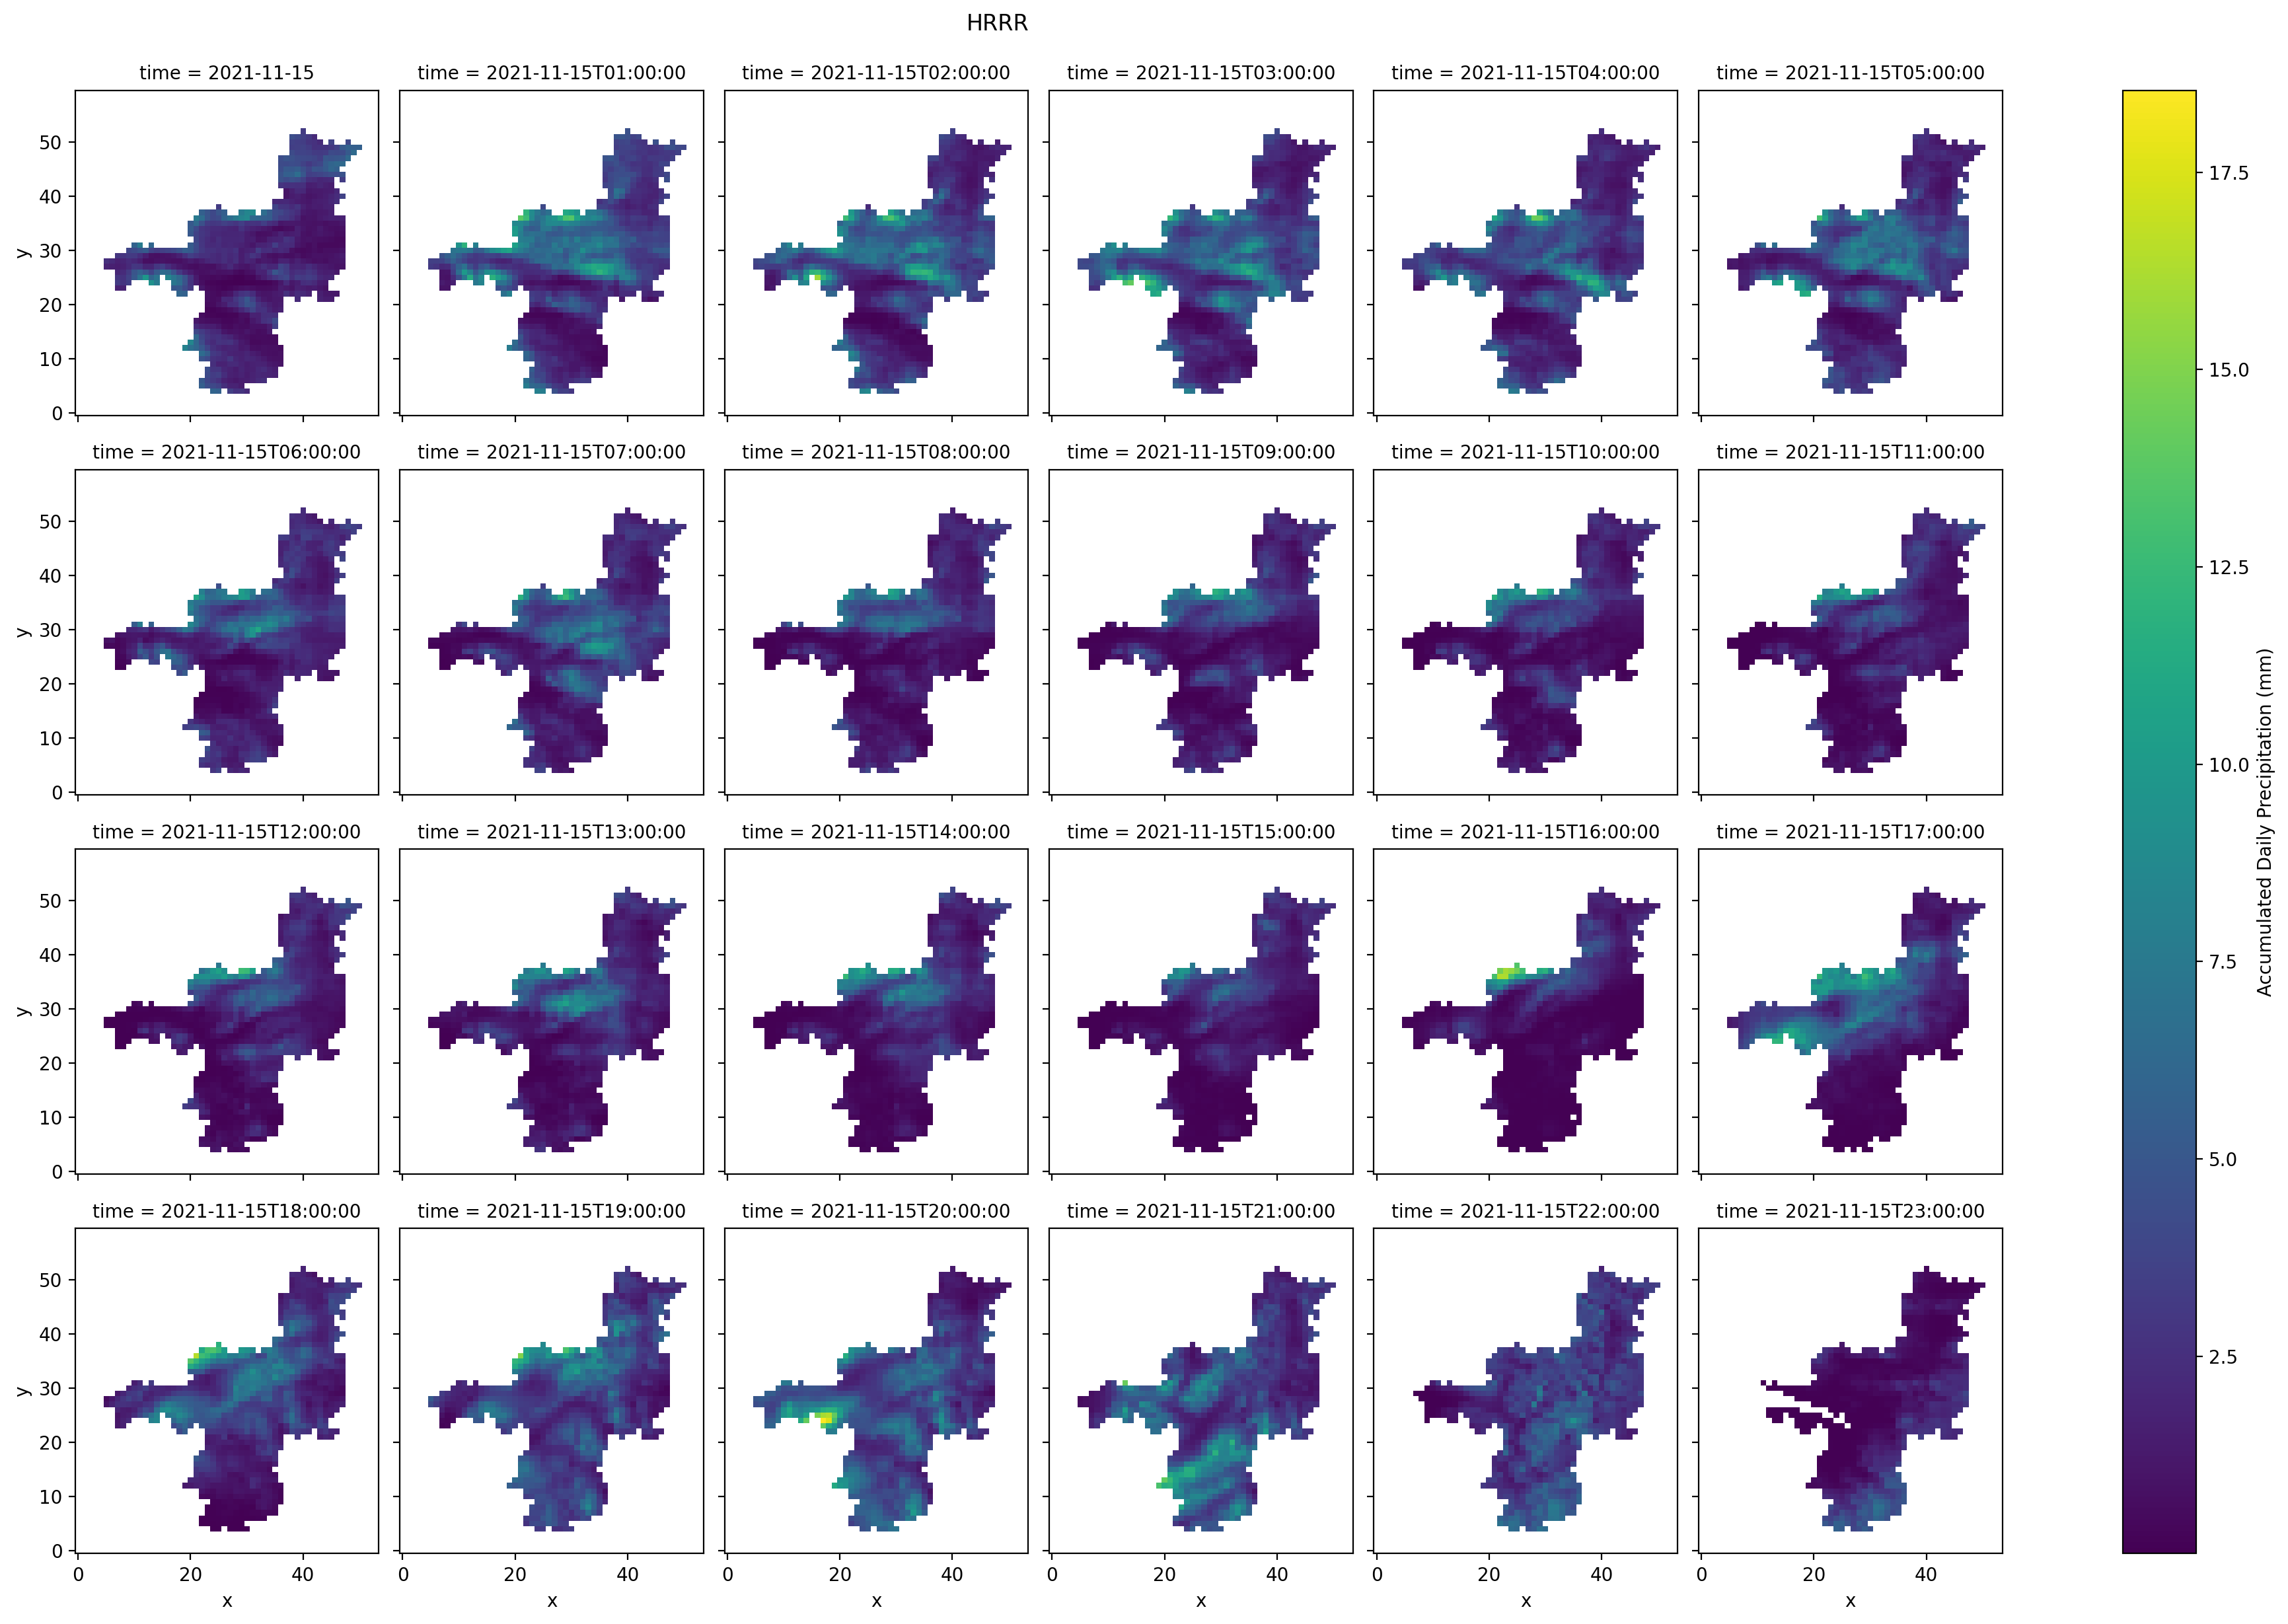

In [45]:
# Plot 24 subplots for each our of a given day using facetgrid for dH
# Dhow log scale here?
#daH.resample(time='1D').sum(min_count=1)
a = daH.sel(time='2021-11-15').plot.imshow(col='time', col_wrap=6, cmap='viridis',
                                                         cbar_kwargs={'label': 'Accumulated Daily Precipitation (mm)'},
)
a.fig.suptitle('HRRR', x=0.4, y=1.02);

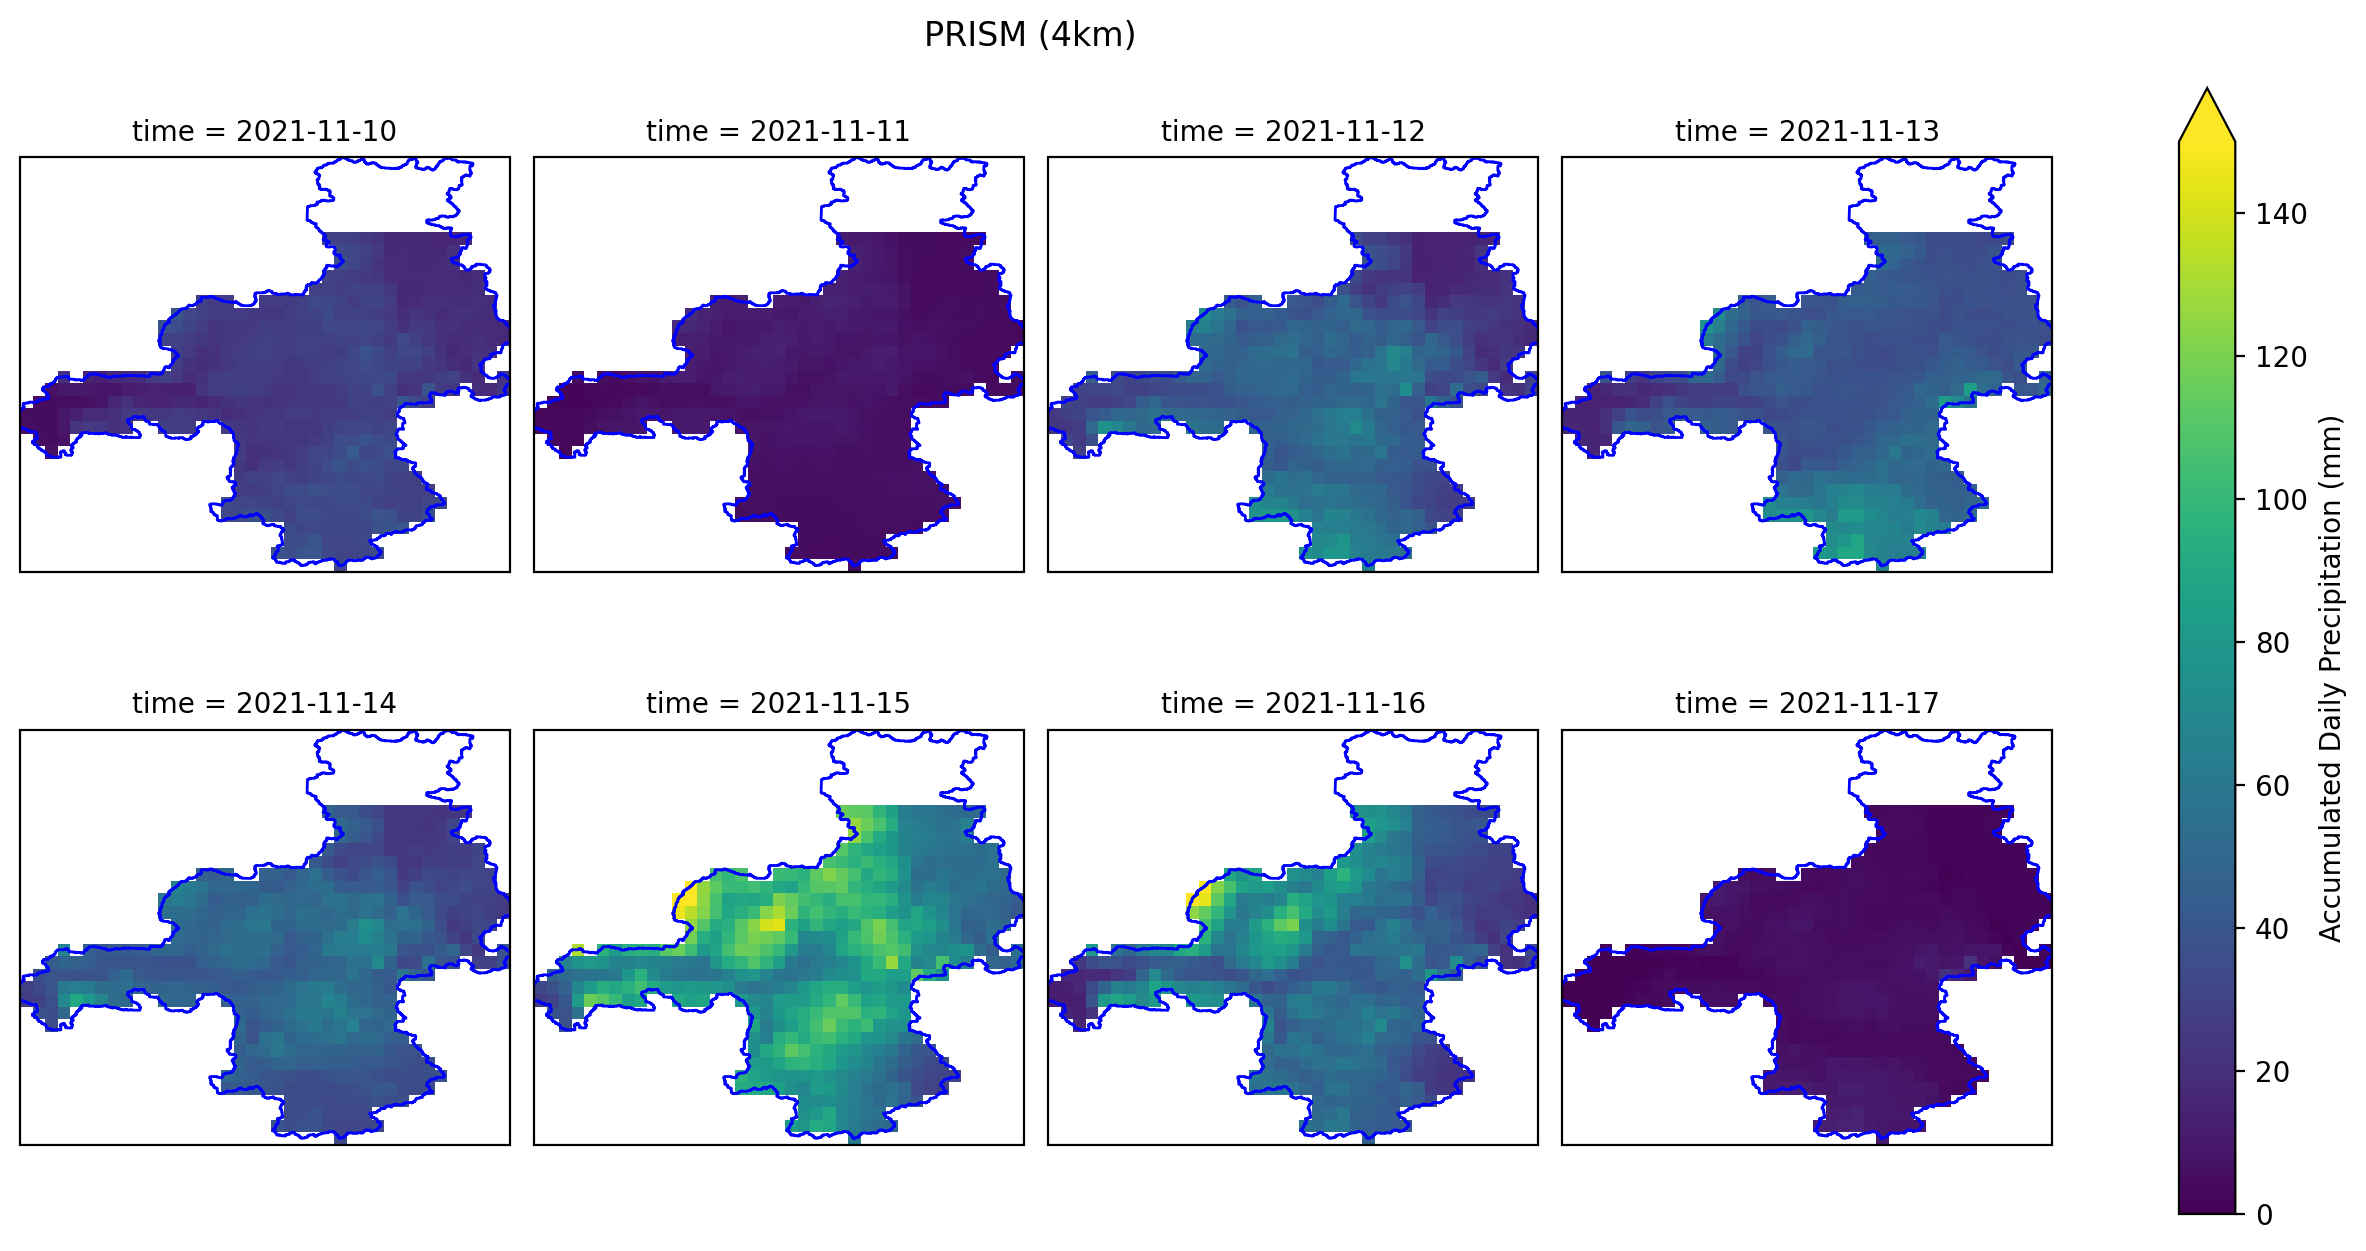

In [46]:
# Use Cartopy for projections and adding basin outlint
aoi_path = '../data/GIS/SkagitBoundary.json'
mask = gpd.read_file(aoi_path)

FC = daP.plot.imshow(
  col='time',
  col_wrap=4,
  cmap='viridis',
  vmin=0,
  vmax=150,
  cbar_kwargs={'label': 'Accumulated Daily Precipitation (mm)'},
  subplot_kws={'projection': ccrs.PlateCarree()}
)
for ax in FC.axs.flat:
    ax.add_geometries([mask.geometry[0]], ccrs.PlateCarree(), edgecolor='blue', facecolor='None');

FC.fig.suptitle('PRISM (4km)', x=0.4, y=1.02);

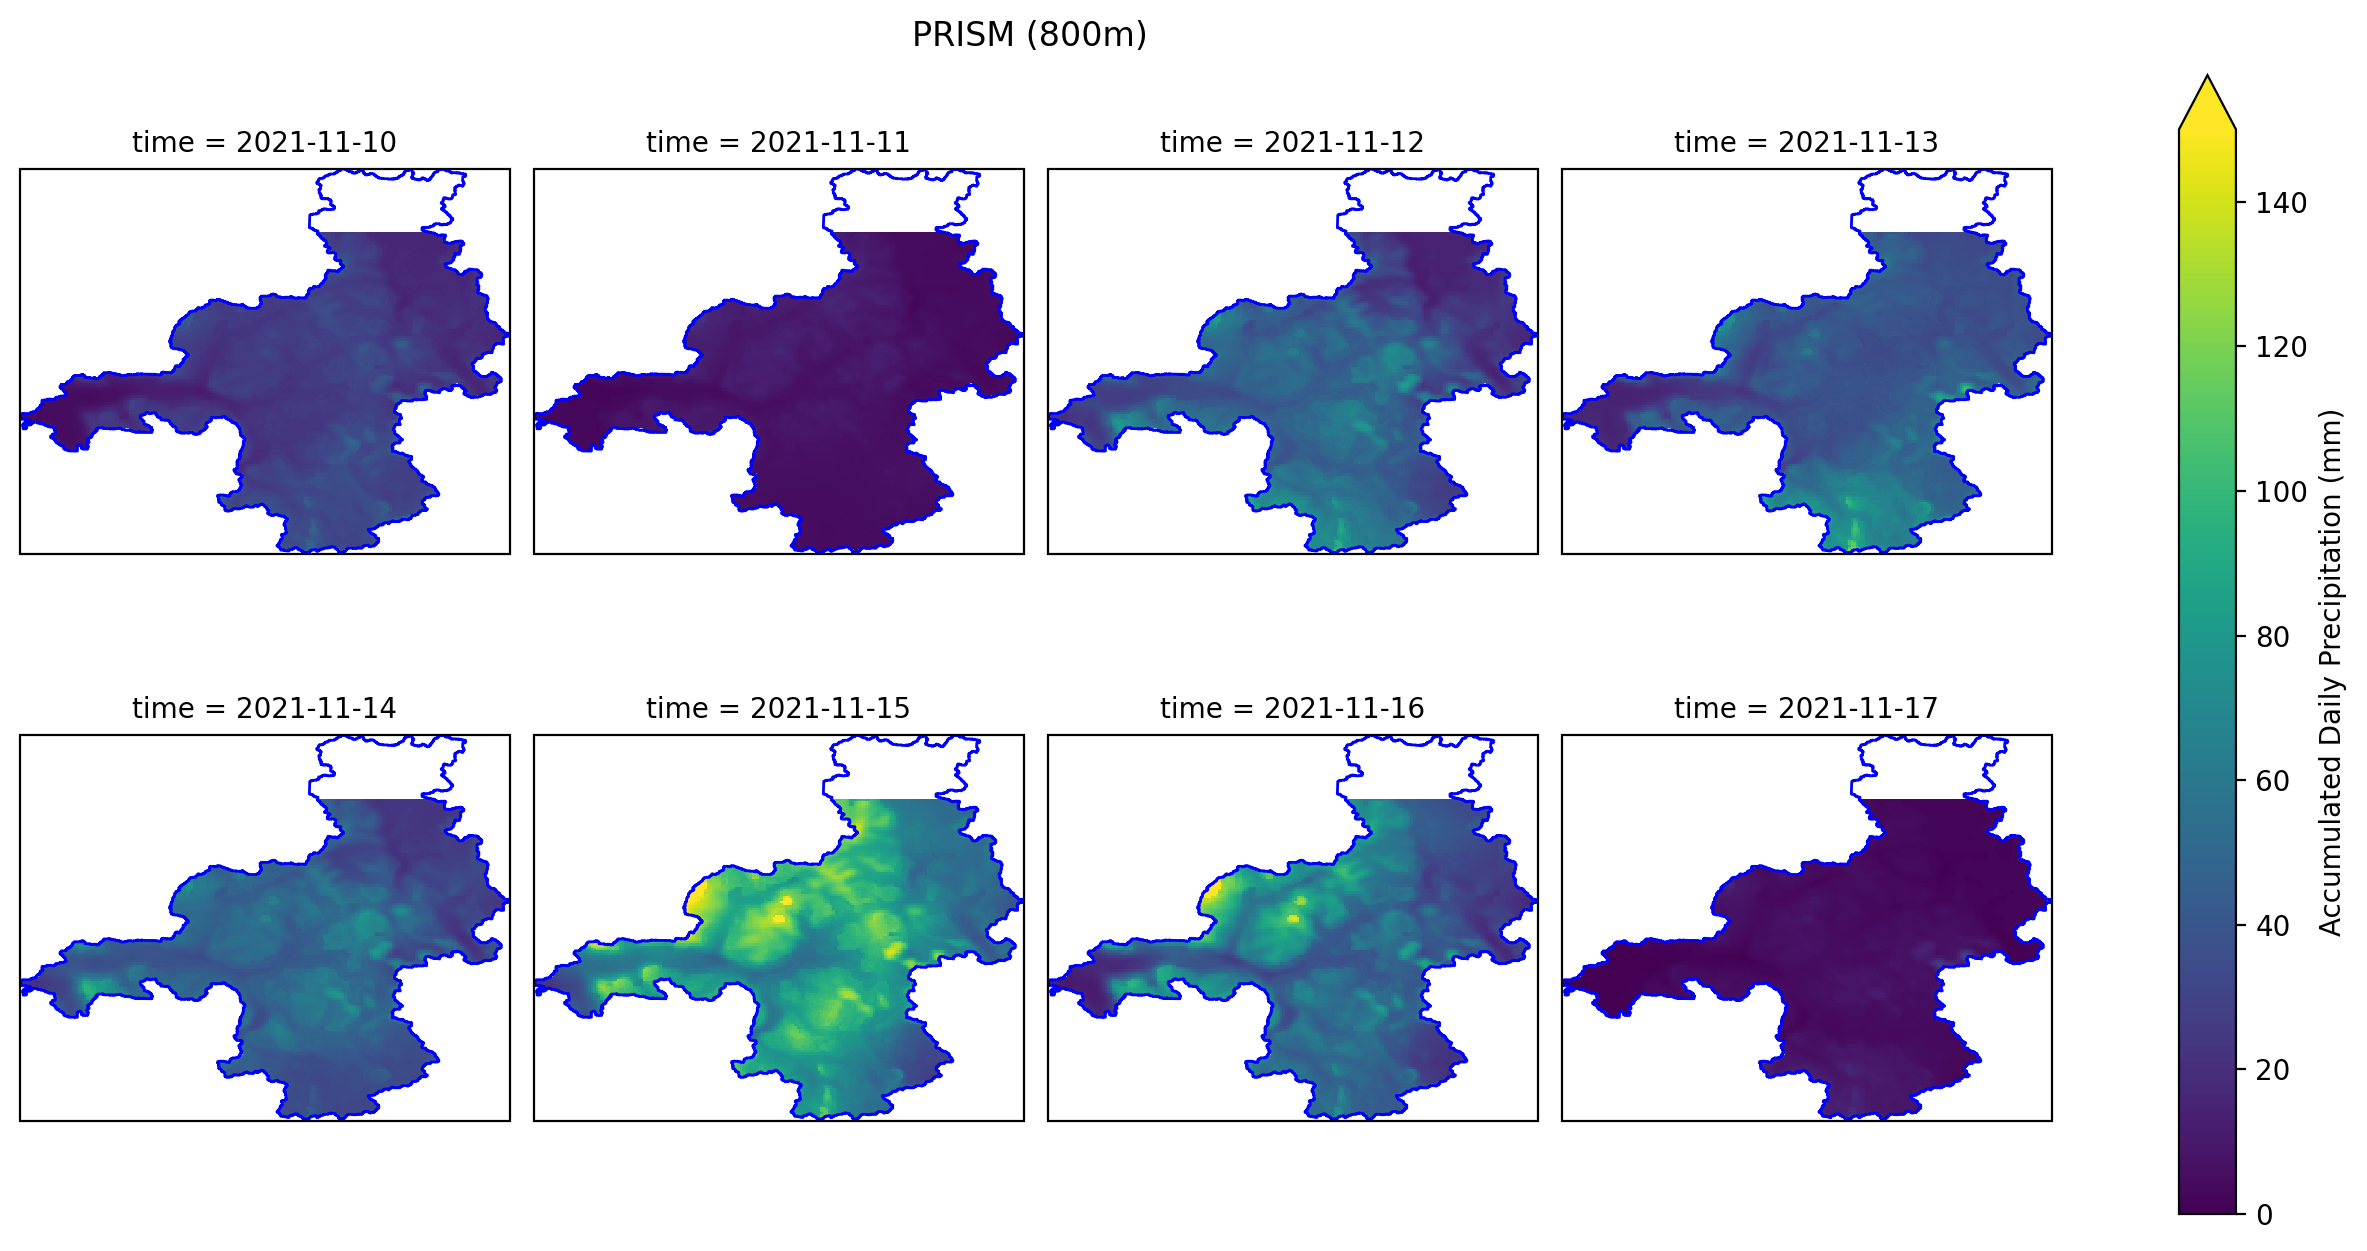

In [47]:
FC = daP8.plot.imshow(
  col='time',
  col_wrap=4,
  cmap='viridis',
  vmin=0,
  vmax=150,
  cbar_kwargs={'label': 'Accumulated Daily Precipitation (mm)'},
  subplot_kws={'projection': ccrs.PlateCarree()}
)
for ax in FC.axs.flat:
    ax.add_geometries([mask.geometry[0]], ccrs.PlateCarree(), edgecolor='blue', facecolor='None');

FC.fig.suptitle('PRISM (800m)', x=0.4, y=1.02);

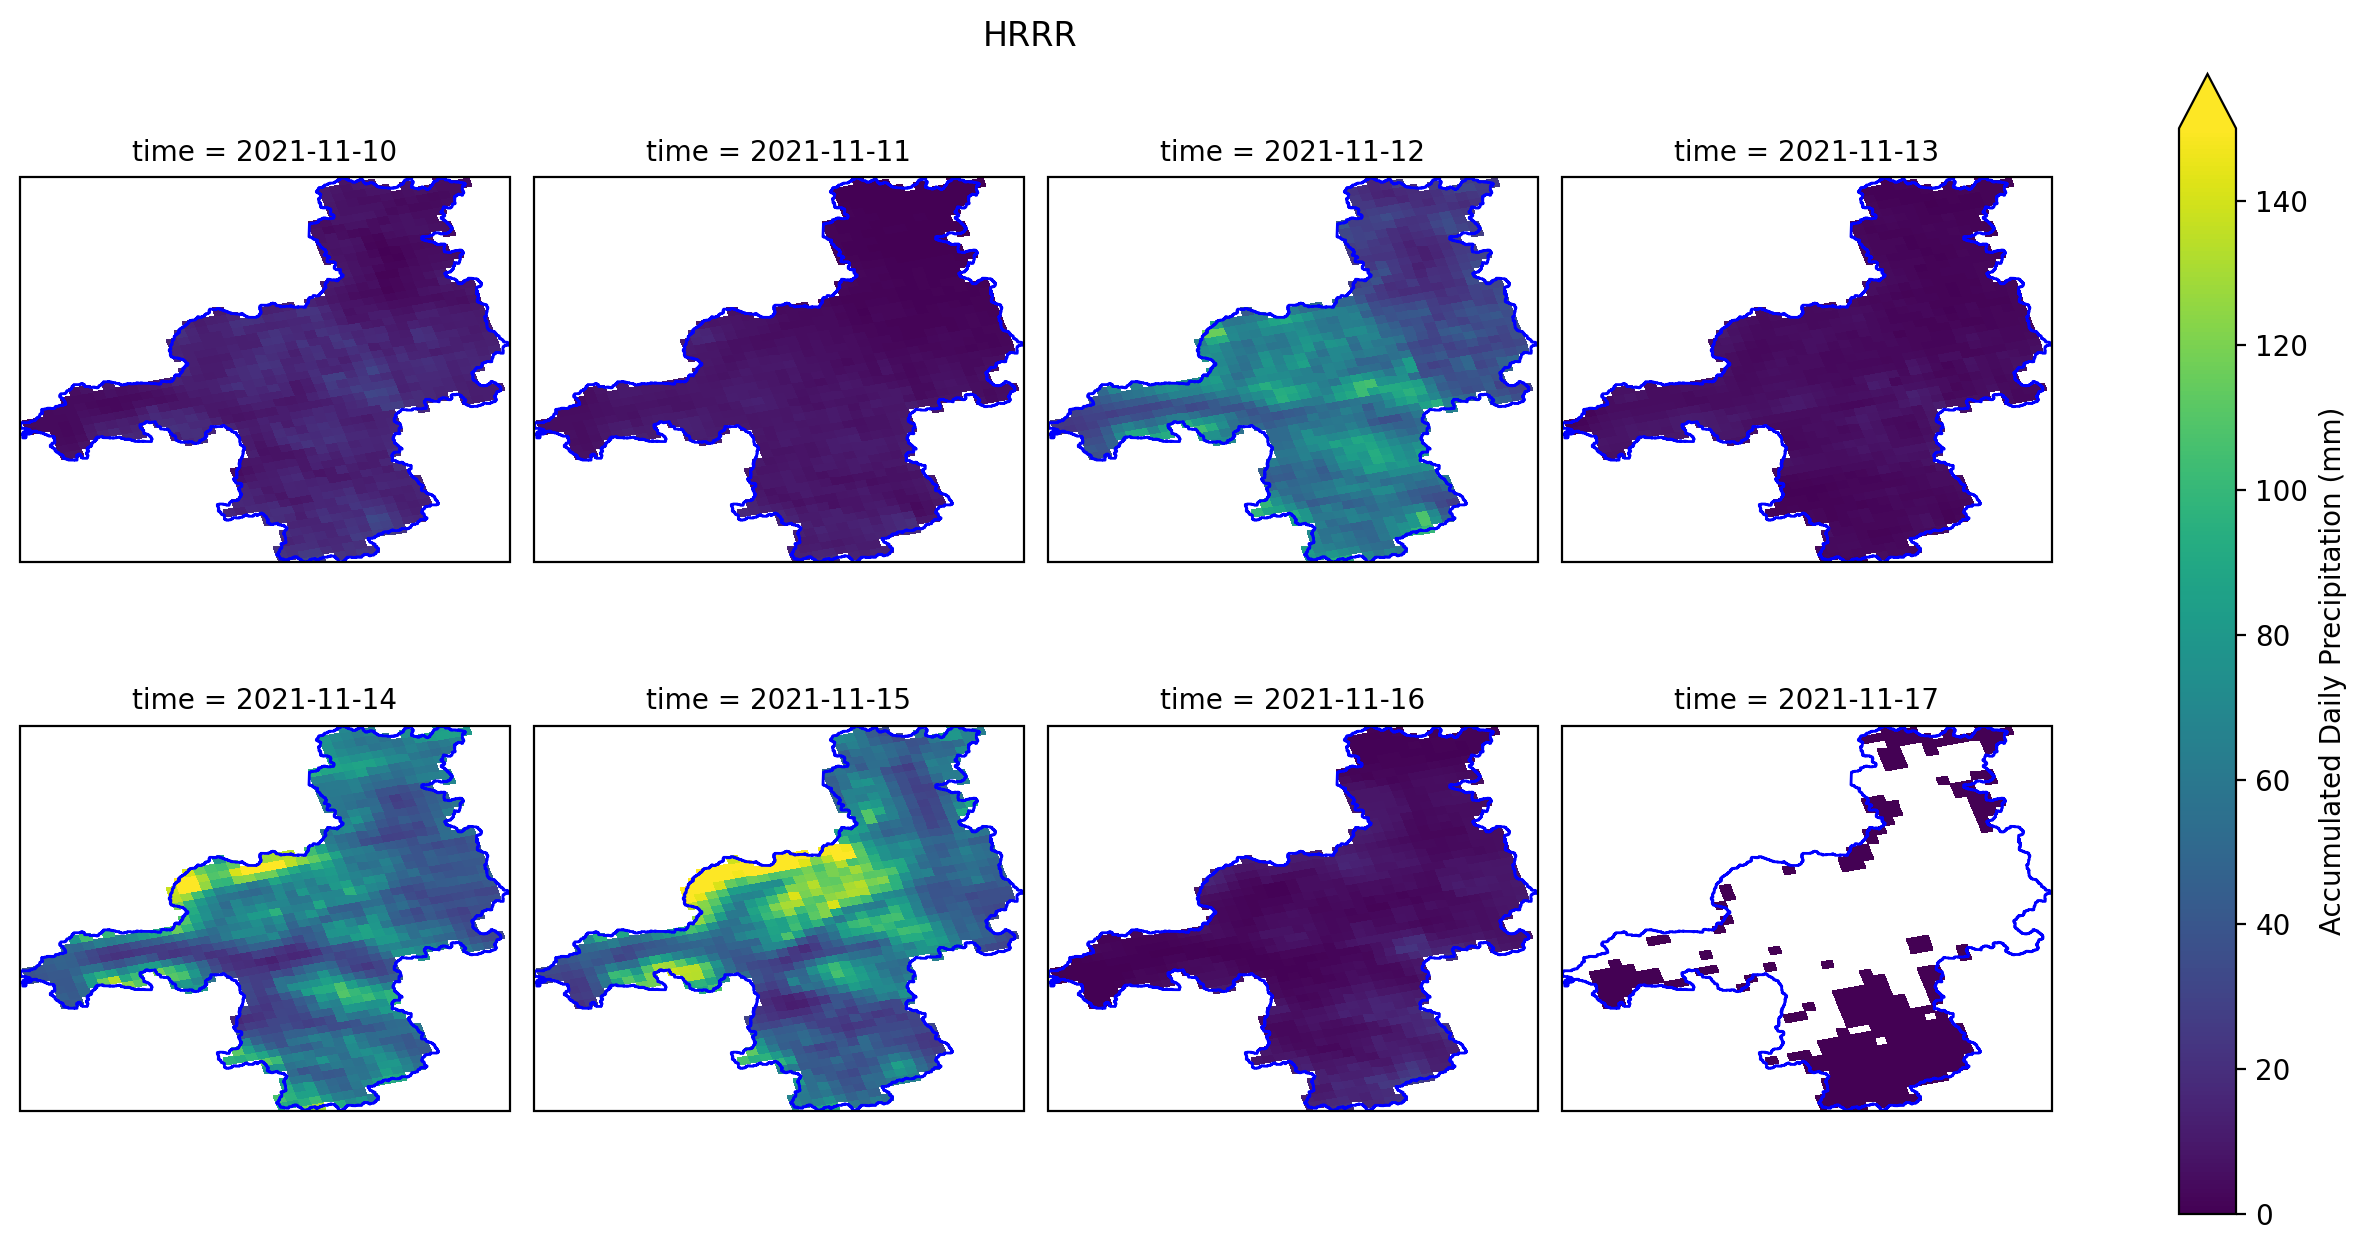

In [48]:
# Use Cartopy for projections and adding basin outlint
aoi_path = '../data/GIS/SkagitBoundary.json'
mask = gpd.read_file(aoi_path)

FC = daH.resample(time='1D').sum(min_count=1).plot.pcolormesh(
  x="longitude", y="latitude",
  #transform=ccrs.PlateCarree(),
  col='time',
  col_wrap=4,
  cmap='viridis',
  vmin=0,
  vmax=150,
  cbar_kwargs={'label': 'Accumulated Daily Precipitation (mm)'},
  subplot_kws={'projection': ccrs.PlateCarree()}
)
for ax in FC.axs.flat:
    ax.add_geometries([mask.geometry[0]], ccrs.PlateCarree(), edgecolor='blue', facecolor='None');
    # Crop to skagit polygon
    ax.set_xlim(mask.total_bounds[[0,2]])
    ax.set_ylim(mask.total_bounds[[1,3]])


FC.fig.suptitle('HRRR', x=0.4, y=1.02);

In [49]:
da_hrrr = daH.resample(time='1D').sum(min_count=1)
da_hrrr = da_hrrr.rio.write_crs('EPSG:4326')
da_prism = daP.copy()
da_prism = da_prism.rio.write_crs('EPSG:4326')

In [50]:
# To show residuals against PRISM, need to reproject onto the same grid
# First, just re-grid using GDAL 2D curvilinear -> 1D rectilinear coords
da_hrrr_1d = da_hrrr.rio.reproject(
            "EPSG:4326",
            # NOTE: GDAL behind the scenes here refines grid automatically
            # THis is *not* the same as reproject_match
            # src_geoloc_array=(
            #     ds.coords["longitude"].values,
            #     ds.coords["latitude"].values,
            # ),
            # NOTE: I think this just uses nearest neighbor lookups...
            src_geoloc_array=(
                da_hrrr.coords["longitude"].values,
                da_hrrr.coords["latitude"].values,
            ),
            georeferencing_convention="PIXEL_CENTER",
        )
#da_hrrr_1d

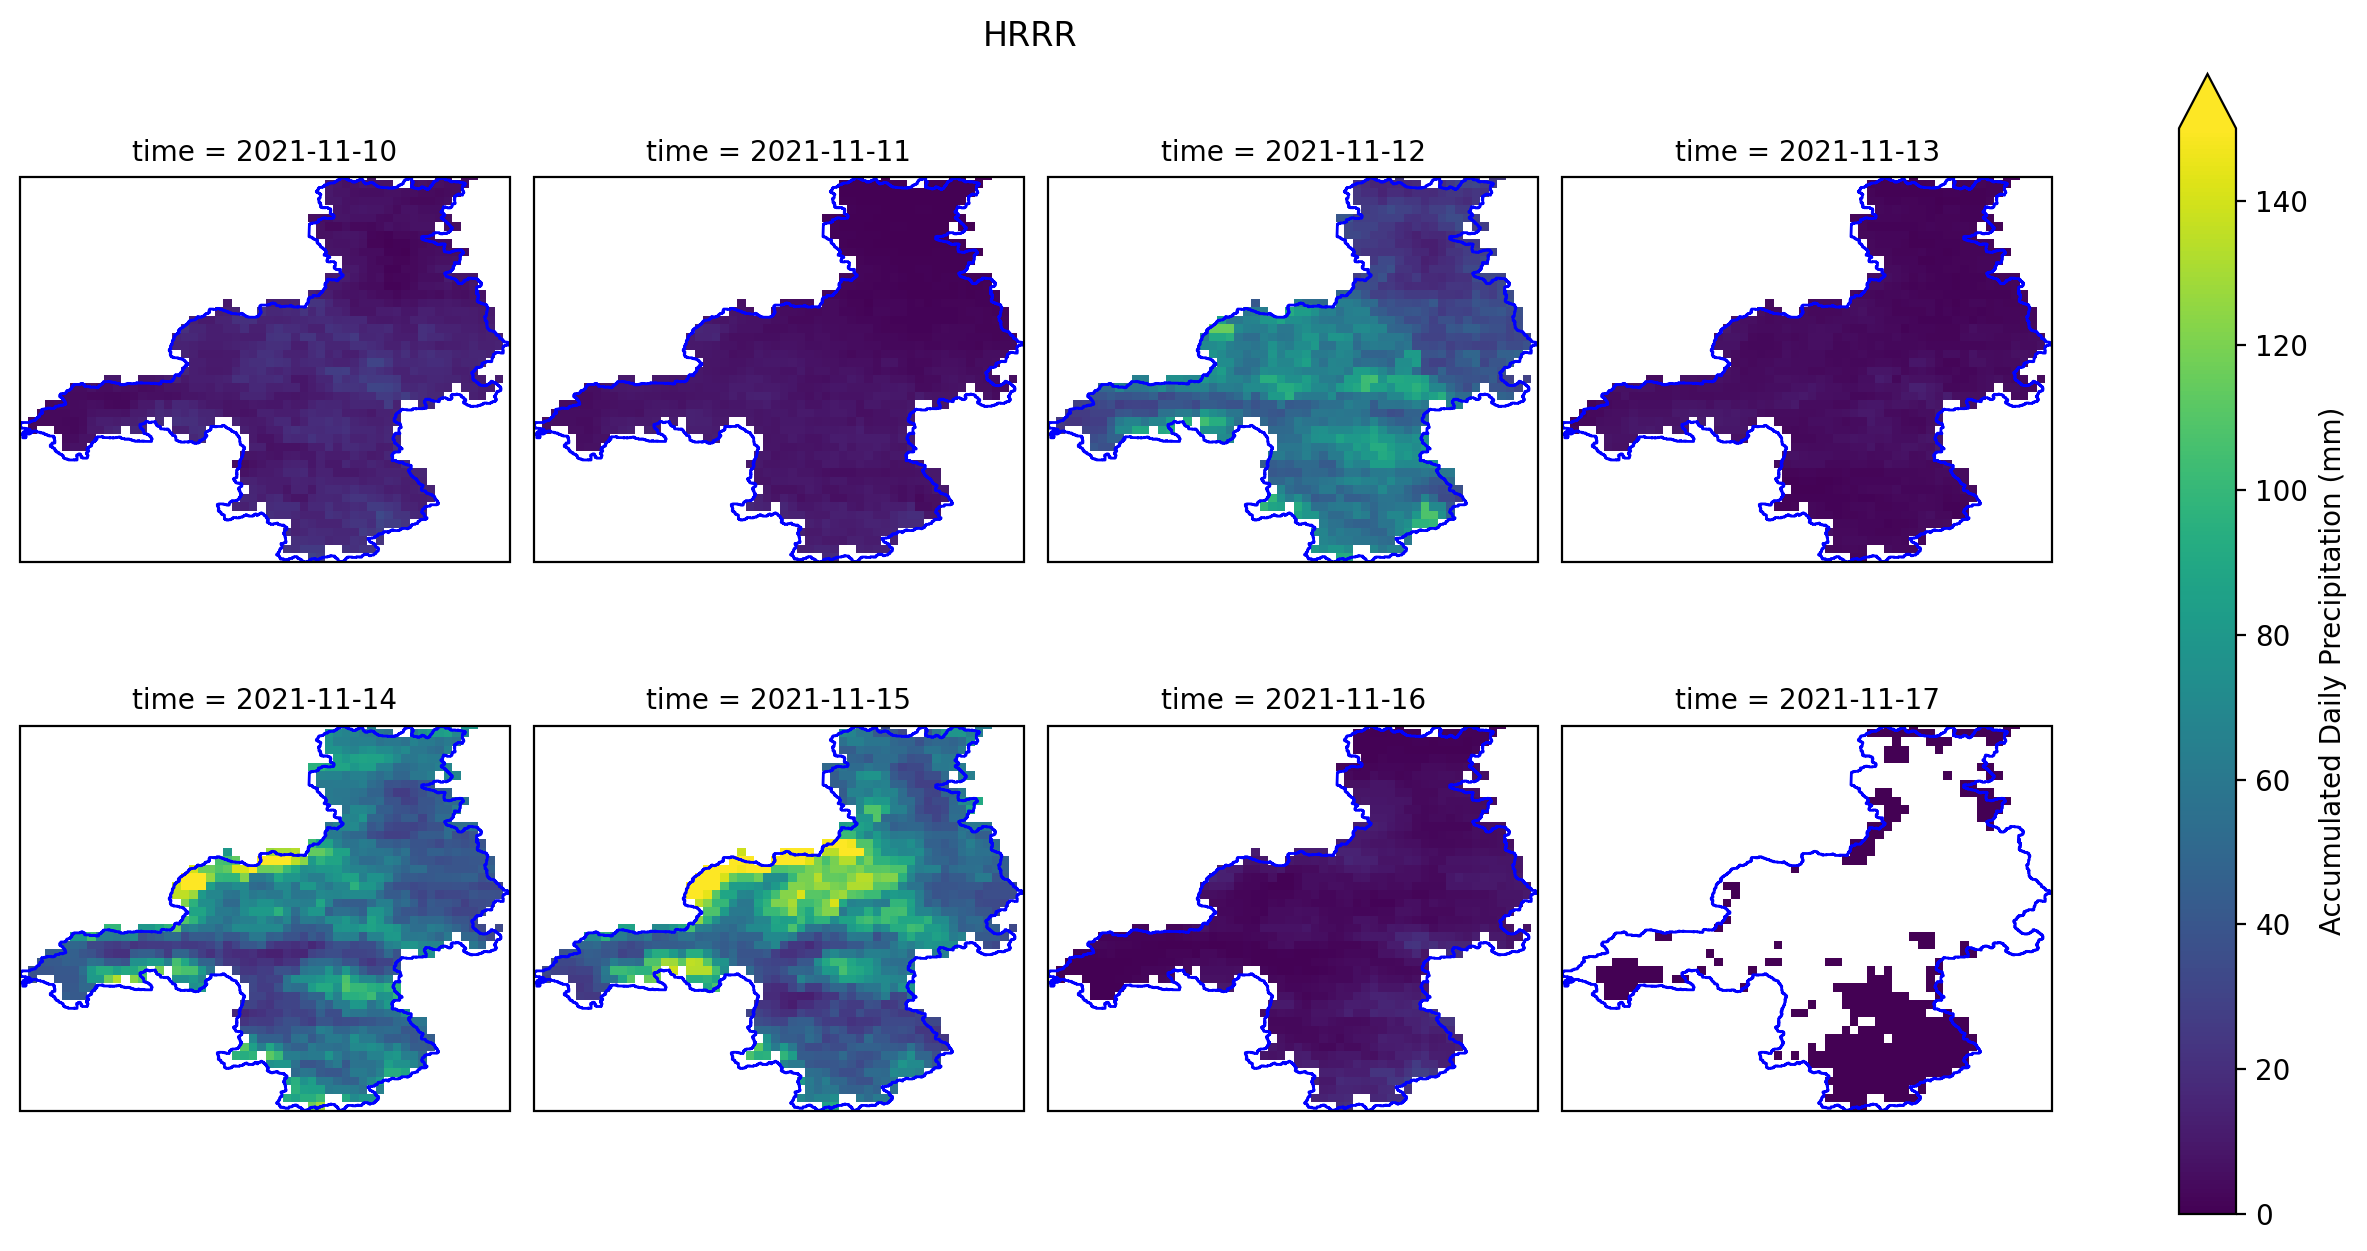

In [51]:
# Use Cartopy for projections and adding basin outlint
aoi_path = '../data/GIS/SkagitBoundary.json'
mask = gpd.read_file(aoi_path)

FC = da_hrrr_1d.plot.imshow(
  col='time',
  col_wrap=4,
  cmap='viridis',
  vmin=0,
  vmax=150,
  cbar_kwargs={'label': 'Accumulated Daily Precipitation (mm)'},
  subplot_kws={'projection': ccrs.PlateCarree()}
)
for ax in FC.axs.flat:
    ax.add_geometries([mask.geometry[0]], ccrs.PlateCarree(), edgecolor='blue', facecolor='None');
    # Crop to skagit polygon
    ax.set_xlim(mask.total_bounds[[0,2]])
    ax.set_ylim(mask.total_bounds[[1,3]])


FC.fig.suptitle('HRRR', x=0.4, y=1.02);

In [52]:
#da_hrrr # y: 60x: 54
#da_prism # lat: 33 lon: 39

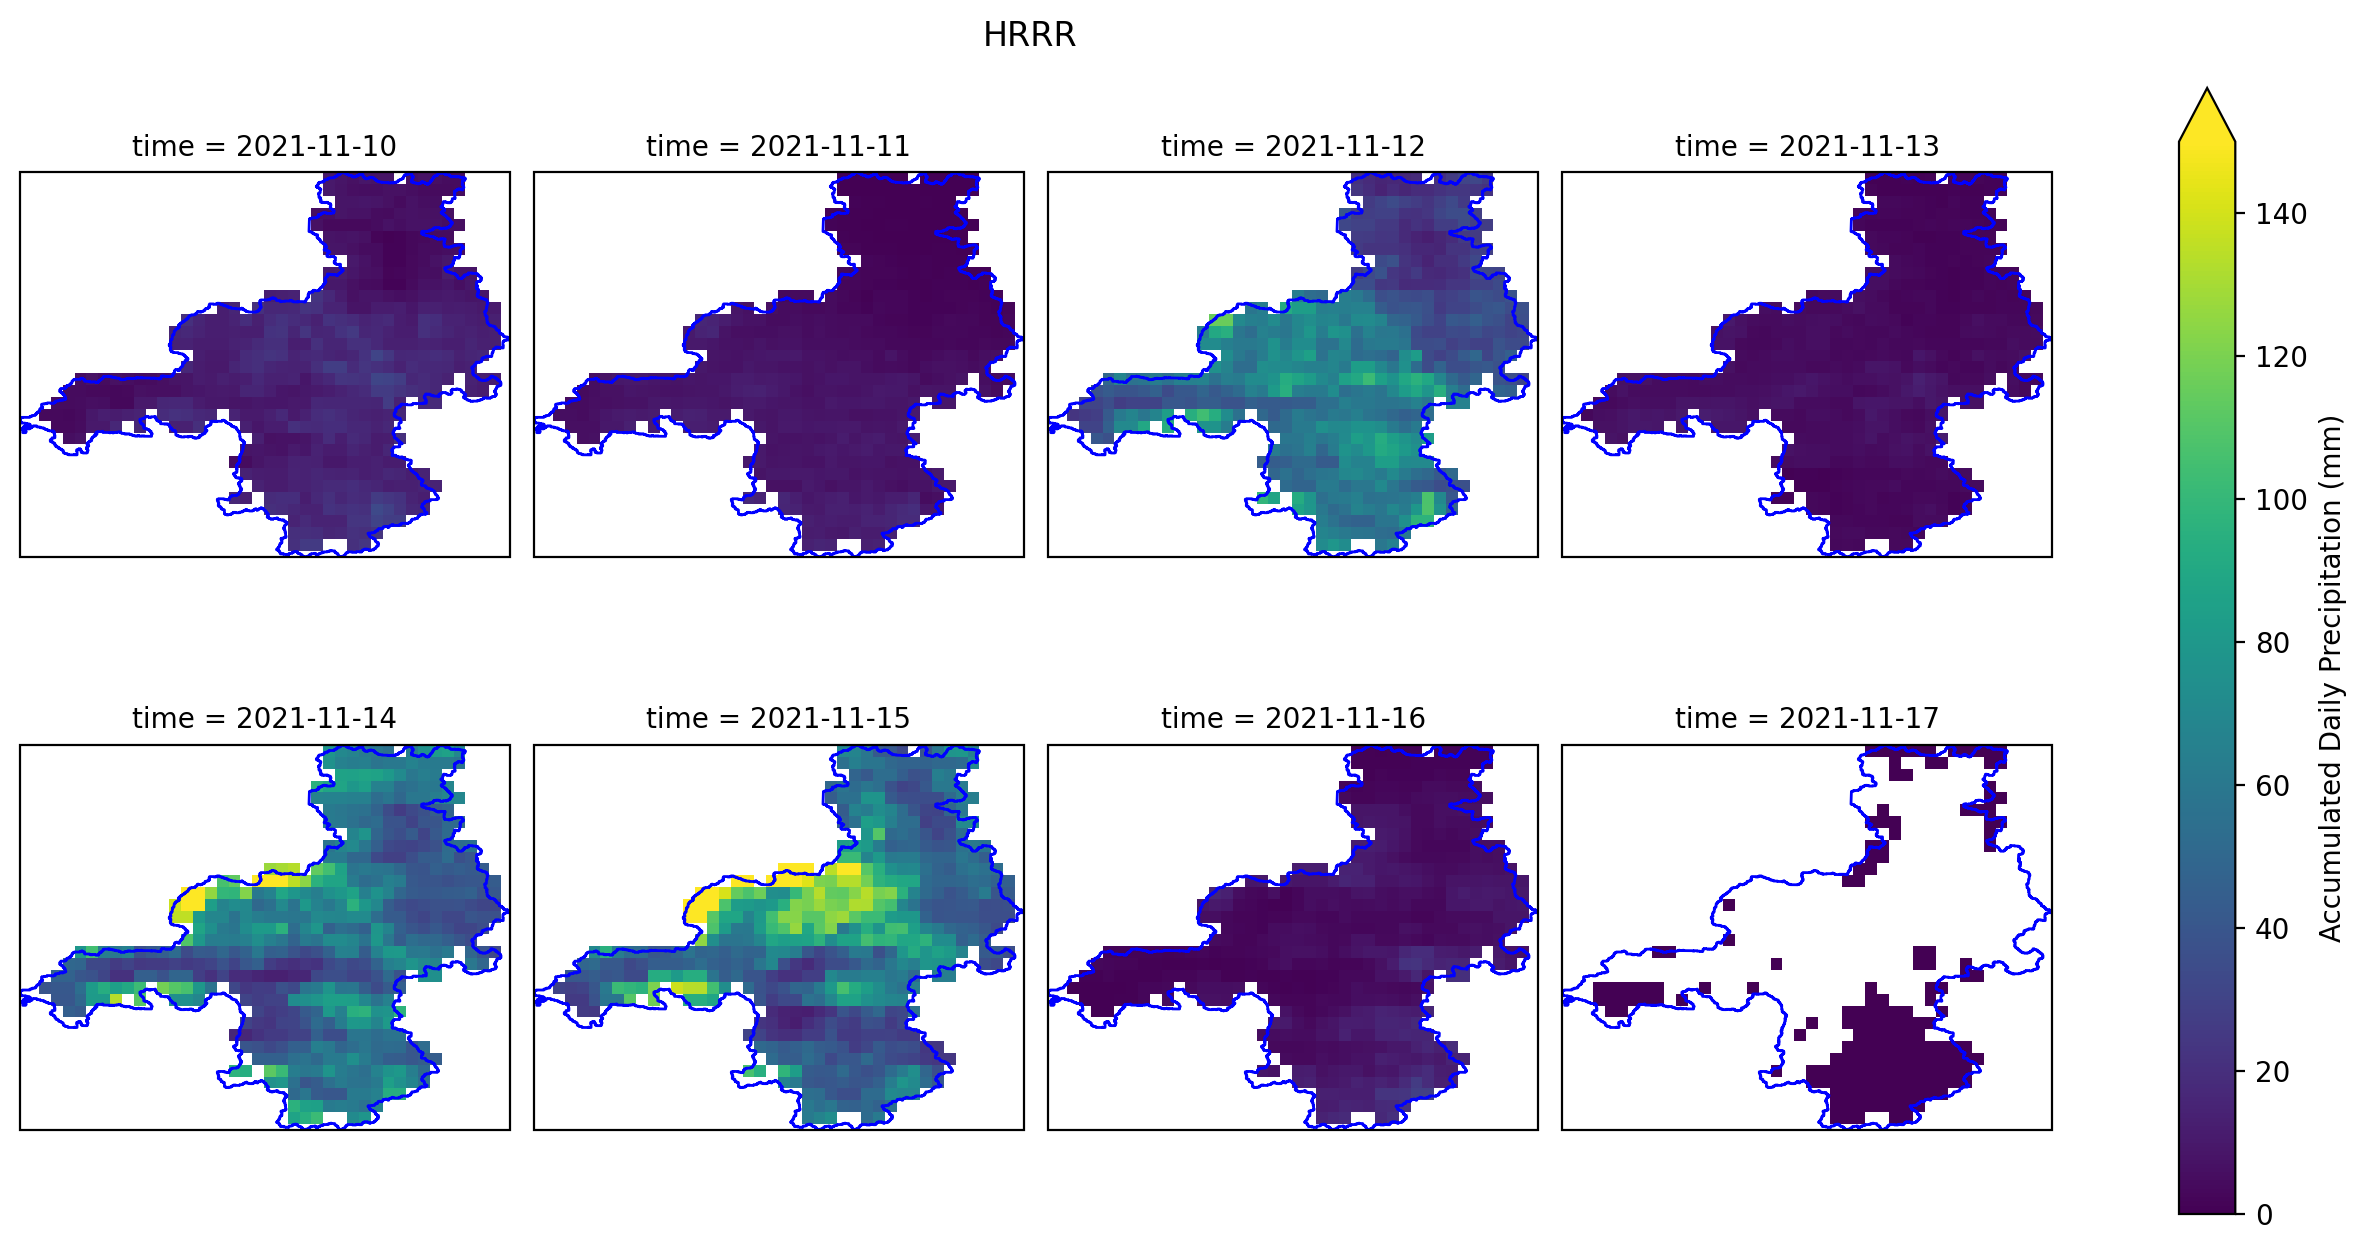

In [53]:
# Instead use reproject_match
# 2D -> 1D doesn't work in one go (all nans!)
#test = da_hrrr.rio.reproject_match(da_prism)  # Finer -> Coarser grid
test = da_hrrr_1d.rio.reproject_match(da_prism)  # Finer -> Coarser grid

FC = test.plot.imshow(
  col='time',
  col_wrap=4,
  cmap='viridis',
  vmin=0,
  vmax=150,
  cbar_kwargs={'label': 'Accumulated Daily Precipitation (mm)'},
  subplot_kws={'projection': ccrs.PlateCarree()}
)
for ax in FC.axs.flat:
    ax.add_geometries([mask.geometry[0]], ccrs.PlateCarree(), edgecolor='blue', facecolor='None');
    # Crop to skagit polygon
    ax.set_xlim(mask.total_bounds[[0,2]])
    ax.set_ylim(mask.total_bounds[[1,3]])


FC.fig.suptitle('HRRR', x=0.4, y=1.02);

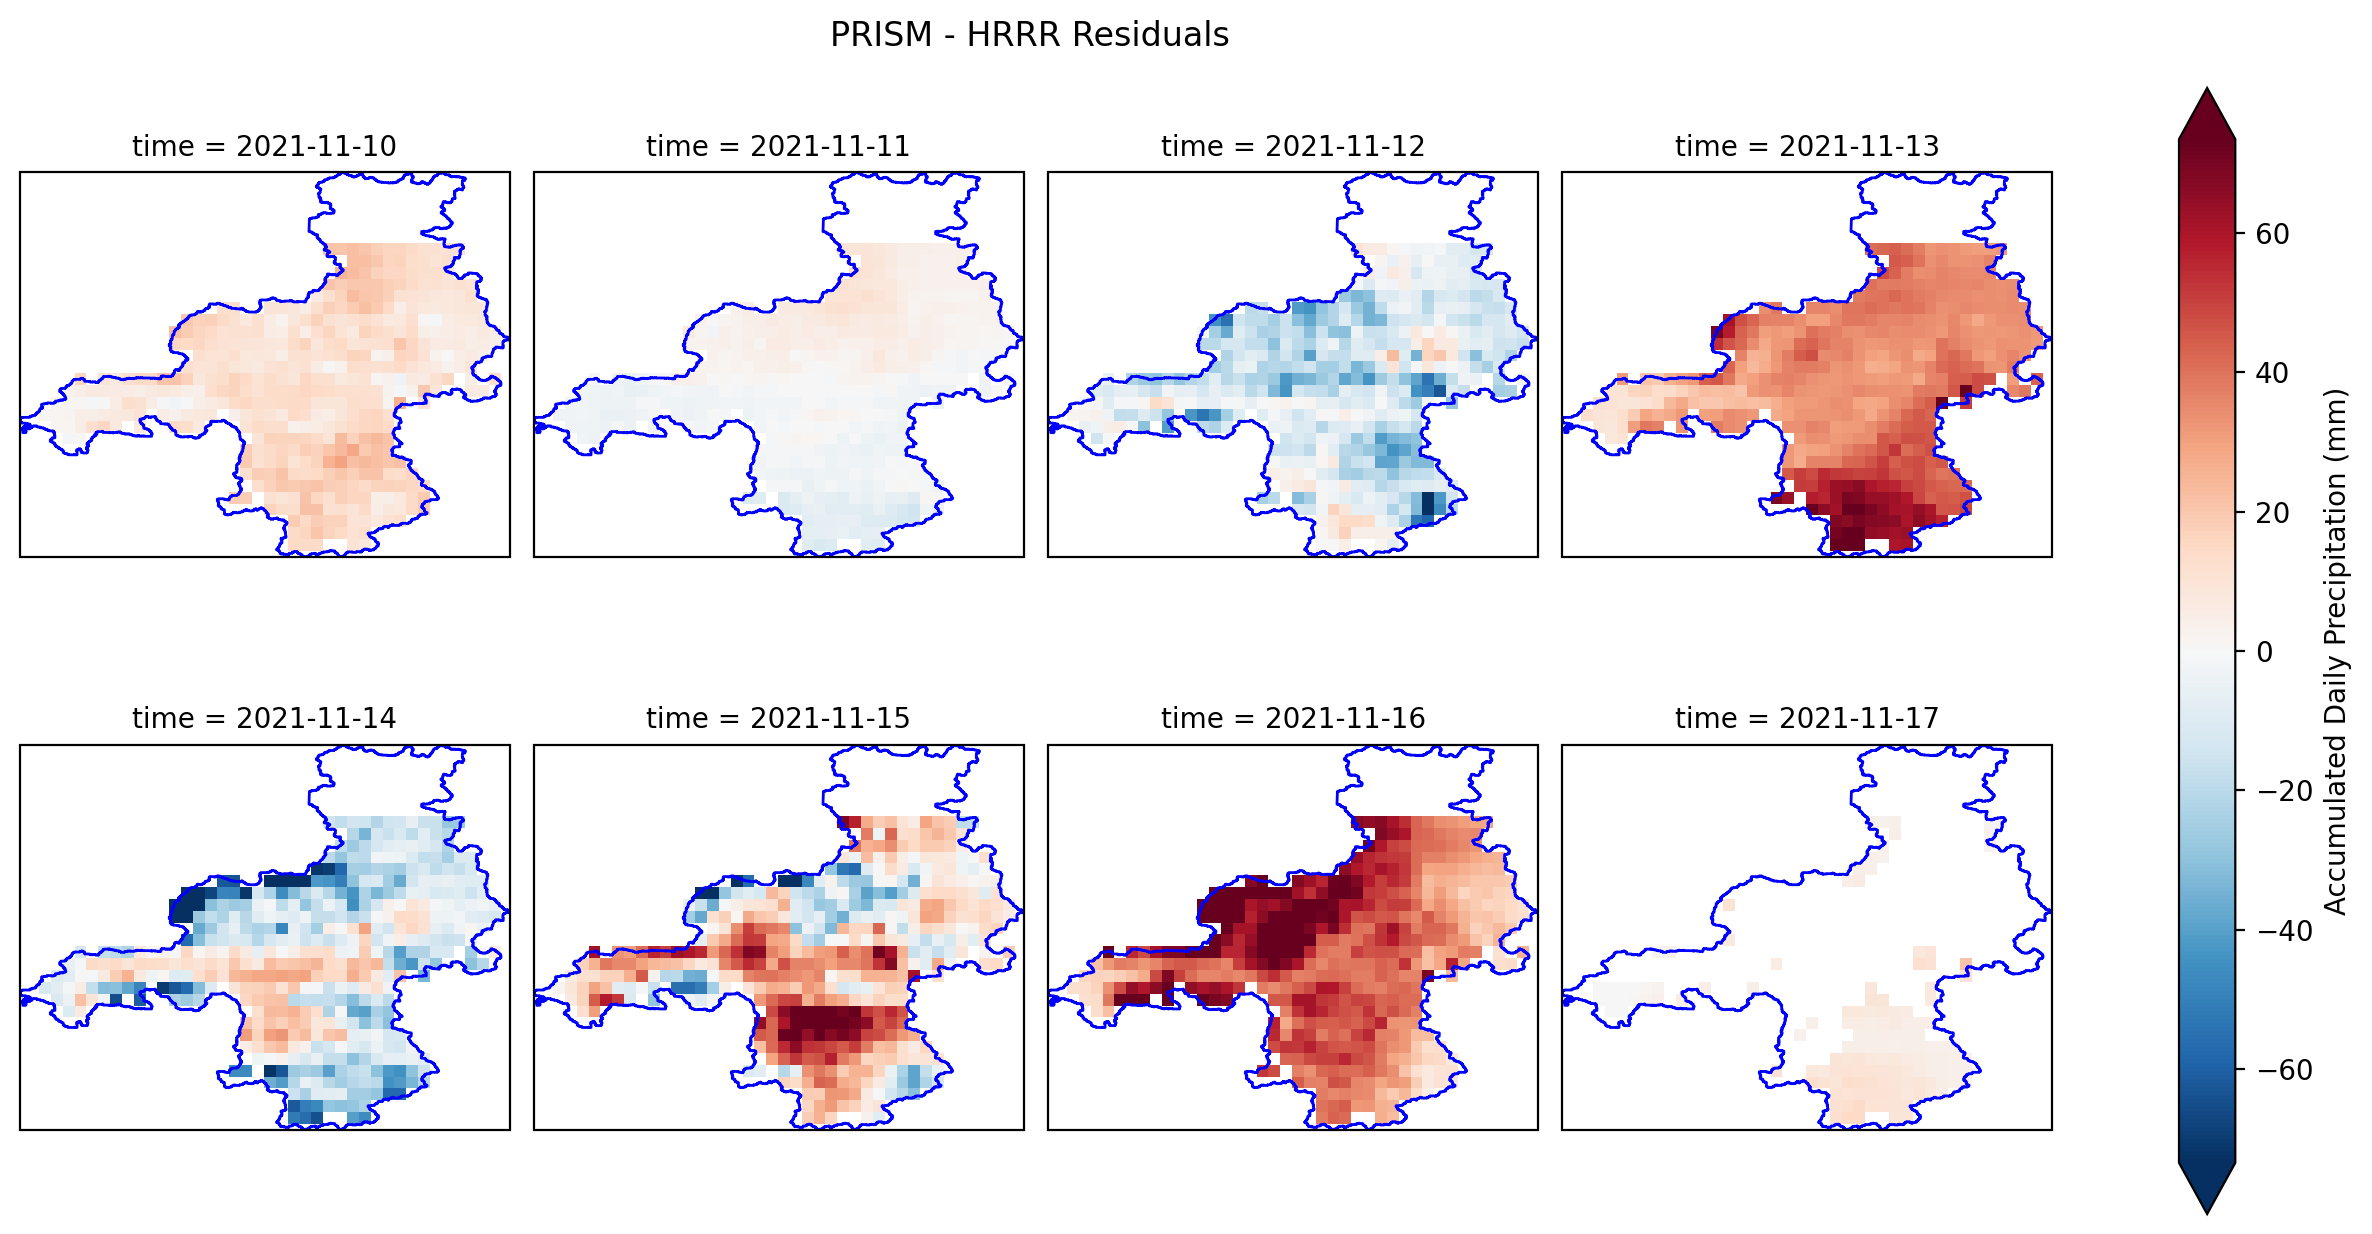

In [54]:
da_diff = da_prism - test.rename({'x':'lon', 'y':'lat'})

FC = da_diff.plot.imshow(
  col='time',
  col_wrap=4,
  #cmap='viridis',
  robust=True,
  cbar_kwargs={'label': 'Accumulated Daily Precipitation (mm)'},
  subplot_kws={'projection': ccrs.PlateCarree()}
)
for ax in FC.axs.flat:
    ax.add_geometries([mask.geometry[0]], ccrs.PlateCarree(), edgecolor='blue', facecolor='None');
    # Crop to skagit polygon
    ax.set_xlim(mask.total_bounds[[0,2]])
    ax.set_ylim(mask.total_bounds[[1,3]])


FC.fig.suptitle('PRISM - HRRR Residuals', x=0.4, y=1.02);

In [55]:
# TODO: plot partioning of precip vs elecation.
# Compare to SNOTEL or other in-situ sensors
# Add other products to bar charts, residuals against PRISM


In [56]:
def embedDEM(ds, dem, ds_x, ds_y, dem_x='x', dem_y='y', dem_var=None, method='nearest'):
    # Pick DEM variable
    if dem_var is None:
        dem_var = [v for v in dem.data_vars][0]

    if 'band' in dem[dem_var].dims:
        dem_elev = dem[dem_var].isel(band=0).squeeze()
    else:
        dem_elev = dem[dem_var]

    # If DEM coordinates are 1D, meshgrid to get 2D arrays
    dem_lon = dem[dem_x]
    dem_lat = dem[dem_y]
    if dem_lon.ndim == 1 and dem_lat.ndim == 1:
        dem_lon2d, dem_lat2d = np.meshgrid(dem_lon, dem_lat)
    else:
        dem_lon2d, dem_lat2d = dem_lon, dem_lat

    dem_points = np.column_stack((dem_lon2d.ravel(), dem_lat2d.ravel()))
    dem_values = dem_elev.values.ravel()

    # Get target coordinates
    target_x = ds[ds_x]
    target_y = ds[ds_y]

    # If both are 1D: use xarray.interp
    if target_x.ndim == 1 and target_y.ndim == 1:
        elev_interp = dem_elev.interp(
            {dem_x: target_x, dem_y: target_y}, method=method
        )
        dims = target_y.dims + target_x.dims
        new_ds = ds.assign_coords(elevation=(dims, elev_interp.values))
    # If either is 2D: use griddata
    else:
        # target_x and target_y must be same shape
        elev_interp = griddata(
            points=dem_points,
            values=dem_values,
            xi=(target_x, target_y),
            method=method,
            fill_value=np.nan
        )
        # Use target_y.dims (should be ('y', 'x')) ONCE
        dims = ds[ds_y].dims
        new_ds = ds.assign_coords(elevation=(dims, elev_interp))
    new_ds = new_ds.set_coords('elevation')
    return new_ds

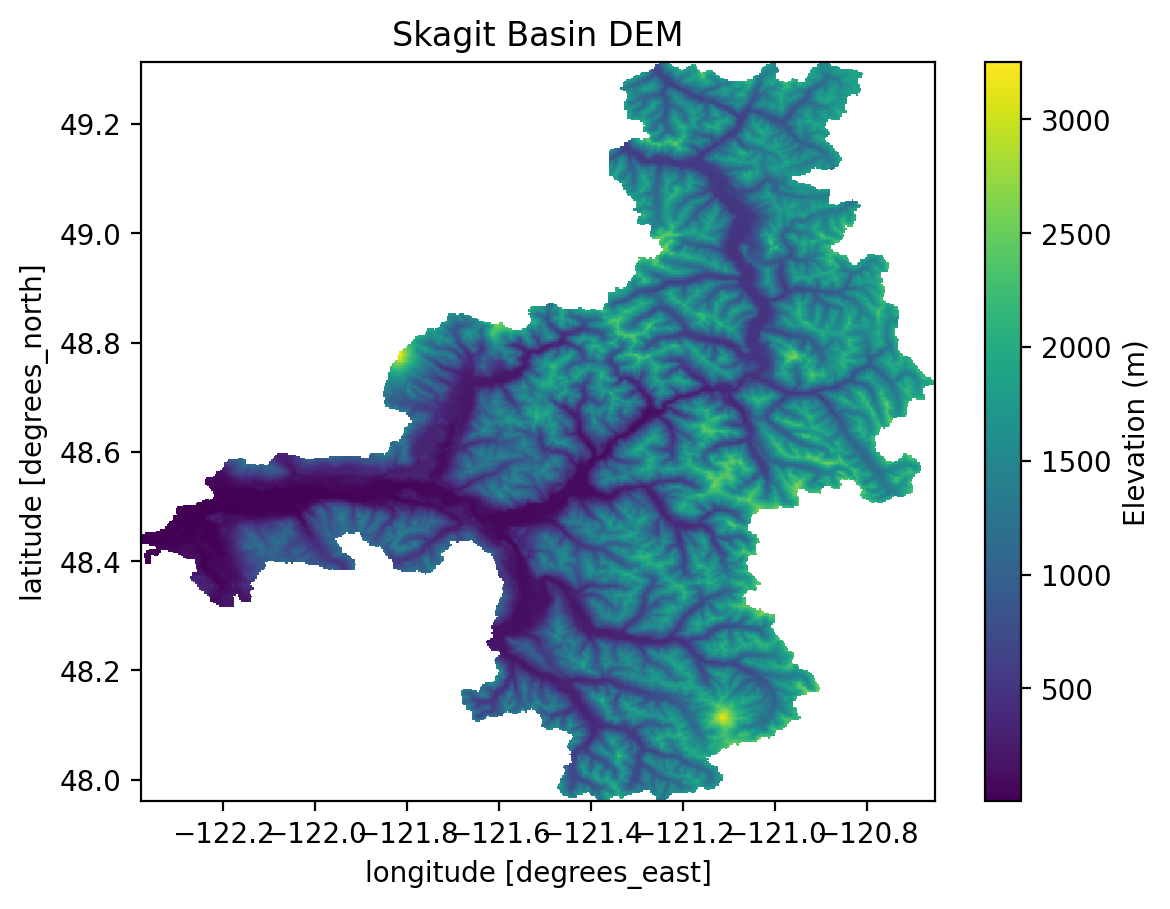

In [57]:
# Load DEM clipped by shapefle and plot
# I think this is SRTM... not sure.
dem = xr.open_dataarray('../data/GIS/SkagitRiver_90mDEM.tif',
                        engine='rasterio').rio.clip(
                            mask.geometry).coarsen(
                                x=10, y=10, boundary='trim').mean().squeeze()
dem.plot.imshow(cbar_kwargs={'label':'Elevation (m)'})
plt.title('Skagit Basin DEM');

In [58]:
da_prism.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

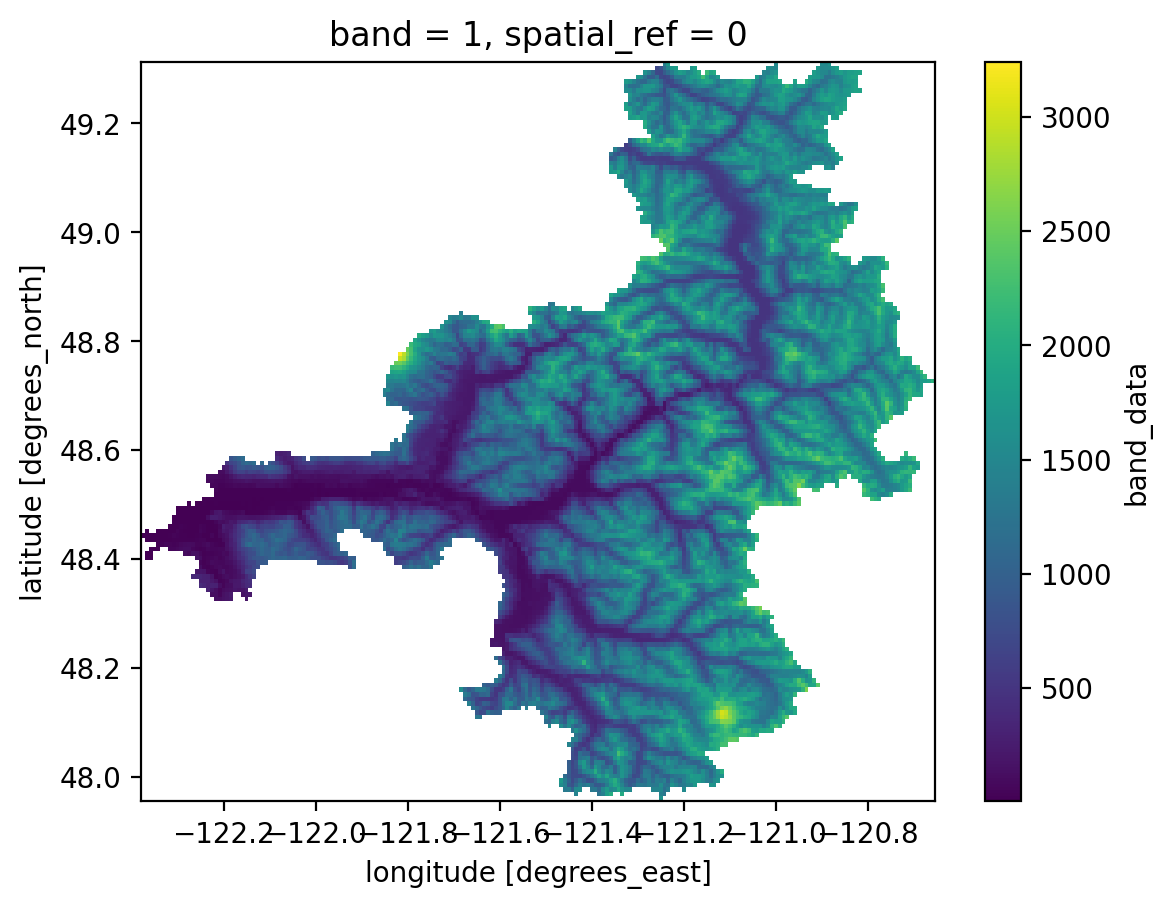

In [59]:
da_p8 = daP8.rio.write_crs('EPSG:4326')
dem = xr.open_dataarray('../data/GIS/SkagitRiver_90mDEM.tif').rio.clip(
                            mask.geometry).squeeze().rio.reproject_match(da_p8)
dem.plot.imshow(robust=False)

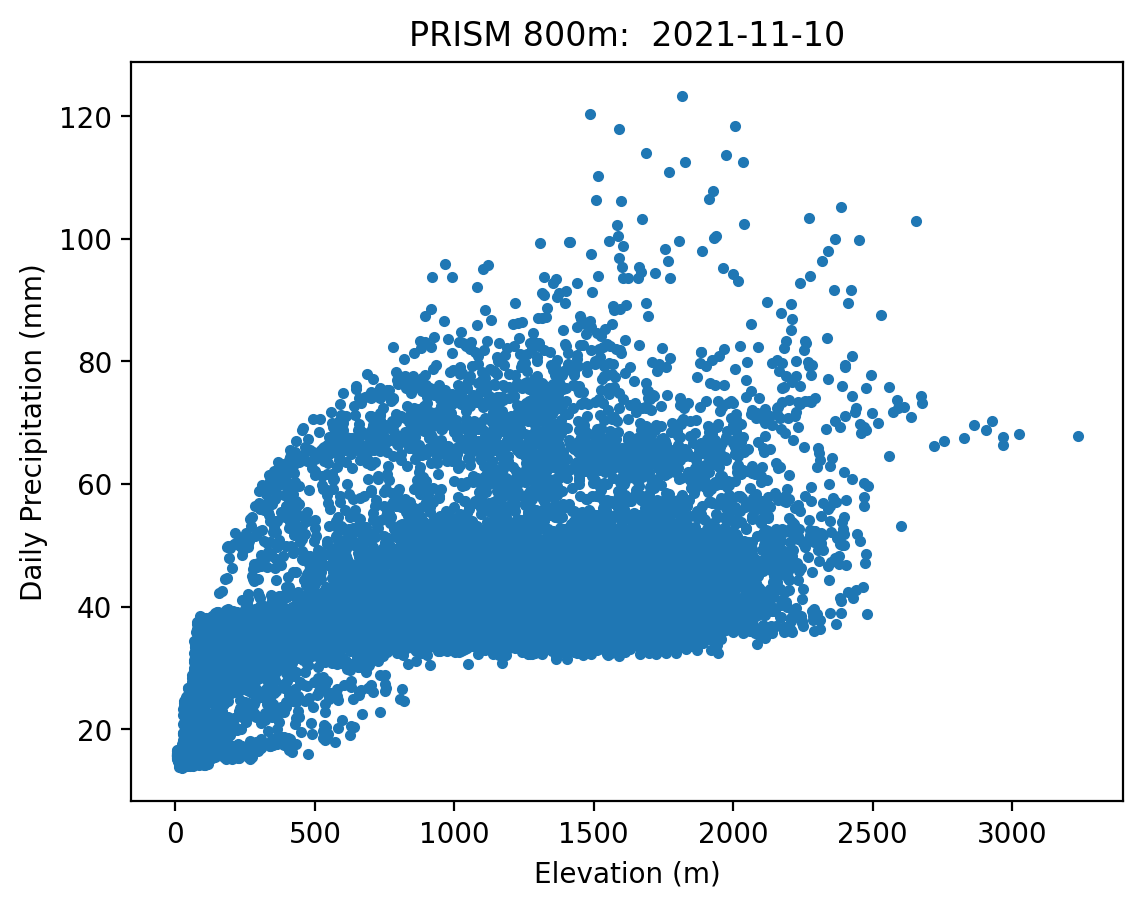

In [60]:
# Put these together in a dataset

plt.scatter(dem, da_p8.isel(time=3),  marker='.')
plt.xlabel('Elevation (m)')
plt.ylabel('Daily Precipitation (mm)')
plt.title(f'PRISM 800m:  {str(da_p8.isel(time=0).time.dt.date.values)}');

In [61]:
# created a context.ipynb for this
#mask.explore()